# 18. ML engineering: pipelines, packaging and MLOps

Everything so far has ended at the same place: a fitted estimator inside a notebook, with a
cross-validated score printed underneath. That is roughly the halfway point of a real
project. A model only creates value when something *outside* the notebook calls it — a
nightly job that scores every customer, a web service that answers in 20 ms, a dashboard
that a retention team looks at on Monday morning — and it keeps creating value only if
somebody notices when the world moves away from the data it was trained on.

This notebook is about that second half. It is not a method notebook: there is no new
learning algorithm here. Instead we take the churn pipeline built in notebook 4 (*data
preprocessing and feature engineering*) and put it through the engineering steps that turn
an experiment into a system: extract it into an importable module, track experiments,
version and persist it with metadata, test it, serve it (batch and online), monitor it for
drift, document it, and decide when to retrain. Everything is implemented from scratch with
the standard library, NumPy, pandas, scikit-learn and Flask, so that you can see what the
specialised tools (MLflow, DVC, Feast, Evidently, Kubernetes) actually do for you before you
adopt them.

**Prerequisites:** notebooks 4 (pipelines and `ColumnTransformer`), 5 (*ML fundamentals:
generalisation and evaluation* — splits, CV, honest test scores) and 12 (*model selection and
hyper-parameter tuning*). Notebook 17 (*model interpretability and explainability*) is useful
for the debugging parts; notebook 19 (*ethics, fairness, privacy and responsible ML*) extends
the governance section.

## Learning objectives

After working through this notebook you will be able to

- describe the ML lifecycle as a loop and name the engineering artefact that each stage produces;
- explain *hidden technical debt* in ML systems (Sculley et al., 2015) and score a project with the *ML test score* rubric (Breck et al., 2017);
- move code out of a notebook into an importable module and import it back, so that training and serving share one definition of a feature;
- make a run reproducible: seeds, pinned environments, hashed data, a configuration file and a minimal experiment tracker you write yourself;
- persist a fitted pipeline together with metadata (versions, data hash, metrics, run id, timestamp), and state the security and version-coupling risks of `pickle`/`joblib`;
- write data-schema checks and behavioural tests (invariance, directional, minimum functionality) for a model, and run them with or without `pytest`;
- serve a model in batch and online, measure latency, and recognise and prevent training–serving skew;
- implement PSI and the Kolmogorov–Smirnov statistic from scratch, detect a simulated distribution shift, and design a monitoring dashboard with delayed labels and retraining triggers;
- write a model card and describe shadow, canary and A/B deployment strategies.

## Setup

In [1]:
import json          # read and write JSON text (run logs, model metadata, HTTP payloads)
import hashlib       # cryptographic hashes (SHA-256), used as content fingerprints of data, code and model files
import importlib     # import and reload modules from code (used for the module written in section 2)
import logging       # the standard library's logging system: messages with levels, sent wherever handlers say
import subprocess    # run other programs (git, the batch-scoring script, pytest) and capture their output
import sys           # the interpreter: sys.path (folders searched on import), sys.modules, sys.executable
import time          # time.perf_counter() is a high-resolution clock for measuring latency
from datetime import datetime, timezone    # timestamps; timezone.utc makes them unambiguous
from pathlib import Path                   # file paths as objects: Path("a") / "b", .read_text(), .exists()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch     # a rectangle with rounded corners, used for the diagram boxes

import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier     # histogram-based gradient boosting (notebook 10)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
# ROC-AUC: how well the scores rank churners above non-churners | average precision: area under the
# precision-recall curve | Brier score: mean squared error between probability and the 0/1 outcome (lower is better)
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

# course helpers: set_style() applies the shared plot style, PALETTE is the list of course colours,
# load_churn() returns the cleaned churn table (used once below as a cross-check)
from course_utils import set_style, PALETTE, load_churn

RANDOM_STATE = 42                            # one fixed seed for every split, model and sample
rng = np.random.default_rng(RANDOM_STATE)    # a seeded random-number generator (used for the run ids in section 3)
set_style()

ARTIFACTS = Path("artifacts")          # every file this notebook writes goes here
# Path / "name" joins paths; parents=True also creates missing parent folders, exist_ok=True: no error if it exists
(ARTIFACTS / "models").mkdir(parents=True, exist_ok=True)
print(f"scikit-learn {sklearn.__version__} | pandas {pd.__version__} | numpy {np.__version__}")
print(f"artifacts directory: {ARTIFACTS.resolve()}")      # .resolve() turns the relative path into an absolute one

scikit-learn 1.8.0 | pandas 3.0.2 | numpy 2.4.4
artifacts directory: /home/claude/ml-course-build/course/notebooks/artifacts


Most figures in this notebook are *diagrams* rather than plots, so we start with two tiny
helpers that draw labelled boxes and arrows on a blank axis. They are used throughout for the
lifecycle, the pipeline, the serving architectures and the retraining logic.

In [2]:
def box(ax, x, y, w, h, text, *, fc="white", ec=PALETTE[0], fontsize=9, weight="normal", lw=1.6):
    """Draw a rounded, labelled rectangle with its lower-left corner at (x, y).

    ax          the matplotlib axes to draw on
    w, h        width and height, in the data coordinates of ax
    text        the label, centred in the box
    fc, ec, lw  fill (face) colour, edge colour and edge line width; fontsize and weight style the label
    The bare * in the signature makes every argument after it keyword-only: box(..., fc="red"), never positional.
    """
    # boxstyle sets the padding and corner radius; zorder=2 draws the box above the arrows (zorder=1)
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.015,rounding_size=0.06",
                                facecolor=fc, edgecolor=ec, linewidth=lw, zorder=2))
    # the label in the centre of the box, on top of everything (zorder=3)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize,
            weight=weight, zorder=3)


def arrow(ax, p0, p1, *, color="0.35", rad=0.0, lw=1.6, label=None, fontsize=8, dy=0.12):
    """Draw an arrow from p0 to p1, optionally labelled at its midpoint.

    p0, p1      (x, y) start and end points, in data coordinates
    color       a number in a string is a grey level (0 = black, 1 = white)
    rad         curvature: 0 is straight, positive and negative values bend the arrow to either side
    label, dy   optional text, placed dy above the midpoint of the arrow
    """
    # annotate with empty text draws only an arrow, from xytext to xy; "-|>" is a filled arrow head,
    # "arc3,rad=..." bends the line, shrinkA / shrinkB leave a small gap (in points) at both ends
    ax.annotate("", xy=p1, xytext=p0,
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw,
                                connectionstyle=f"arc3,rad={rad}", shrinkA=2, shrinkB=2), zorder=1)
    if label:                                        # None (no label) counts as False
        ax.text((p0[0] + p1[0]) / 2, (p0[1] + p1[1]) / 2 + dy, label, ha="center", va="bottom",
                fontsize=fontsize, color=color)


def blank_axes(ax, xlim, ylim):
    """Turn an axis into a drawing canvas (no ticks, no grid, no spines).

    xlim, ylim are (min, max) tuples that fix the coordinate system of the drawing; returns the same ax.
    """
    ax.set_xlim(*xlim)                  # *xlim unpacks the tuple (lo, hi) into two arguments
    ax.set_ylim(*ylim)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for s in ax.spines.values():        # the four frame lines around the panel
        s.set_visible(False)
    return ax

## 1. From notebook to system

### 1.1 The ML lifecycle is a loop, not a line

A machine-learning project is often drawn as a pipeline that starts with data and ends with a
deployed model. That picture is wrong in one important way: the last stage feeds back into the
first. Monitoring produces new data, new failure cases and new requirements; the model is
retrained; the problem definition itself changes when the business learns what the model can
and cannot do. Amershi et al. (2019), who observed software teams at Microsoft building ML
features, describe the process as highly iterative with feedback from every stage to every
earlier one.

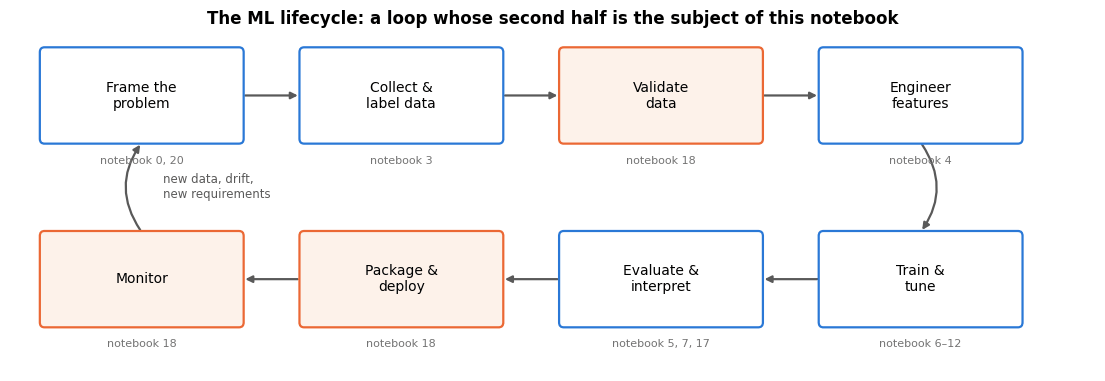

In [3]:
# (label of the box, notebooks that cover that stage); "\n" inside a label starts a new line in the box
stages = [
    ("Frame the\nproblem", "0, 20"), ("Collect &\nlabel data", "3"),
    ("Validate\ndata", "18"), ("Engineer\nfeatures", "4"),
    ("Train &\ntune", "6–12"), ("Evaluate &\ninterpret", "5, 7, 17"),
    ("Package &\ndeploy", "18"), ("Monitor", "18"),
]
fig, ax = plt.subplots(figsize=(14, 4.4))
blank_axes(ax, (0, 14), (0.2, 4.35))
w, h = 2.6, 1.15                     # width and height of every box
top_y, bot_y = 3.0, 0.75             # y position of the top and the bottom row
for i, (name, nb) in enumerate(stages):
    row, col = divmod(i, 4)          # divmod(i, 4) = (i // 4, i % 4): four boxes per row
    # the top row runs left to right, the bottom row right to left (3 - col), so the stages form a loop
    x = 0.4 + col * 3.35 if row == 0 else 0.4 + (3 - col) * 3.35
    y = top_y if row == 0 else bot_y
    accent = PALETTE[1] if nb == "18" else PALETTE[0]      # orange for the stages this notebook covers
    box(ax, x, y, w, h, name, ec=accent, fc="#fdf2ea" if nb == "18" else "white", fontsize=10)
    ax.text(x + w / 2, y - 0.22, f"notebook {nb}", ha="center", va="center", fontsize=8, color="0.45")
    if col < 3:                      # an arrow to the next box, except after the last box of a row
        x0, x1 = (x + w, x + 3.35) if row == 0 else (x, x - 0.75)      # rightwards on top, leftwards below
        arrow(ax, (x0, y + h / 2), (x1, y + h / 2))
# two curved arrows close the loop: down on the right, and back up on the left (the feedback path)
arrow(ax, (0.4 + 3 * 3.35 + w / 2, top_y), (0.4 + 3 * 3.35 + w / 2, bot_y + h), rad=-0.35)
arrow(ax, (0.4 + w / 2, bot_y + h), (0.4 + w / 2, top_y), rad=-0.35)
ax.text(0.4 + w / 2 + 0.28, (top_y + bot_y + h) / 2, "new data, drift,\nnew requirements",
        ha="left", va="center", fontsize=8.5, color="0.35")
ax.set_title("The ML lifecycle: a loop whose second half is the subject of this notebook", fontsize=12)
plt.show()

Every stage produces an **artefact** that someone else (or a future you) must be able to find,
read and trust:

| Stage | Artefact | Where it lives |
|---|---|---|
| Frame the problem | metric definition, cost of an error, success criterion | design doc / README |
| Collect & label | raw dataset with a version identifier | data store + hash / DVC pointer |
| Validate data | a schema and its violations | `schema.json`, validation report |
| Engineer features | feature functions *shared by training and serving* | a module, not a notebook |
| Train & tune | a run log: config, data hash, metrics, seed | experiment tracker |
| Evaluate | held-out metrics, slices, error analysis | evaluation report |
| Package & deploy | a serialised pipeline + metadata + model card | model registry |
| Monitor | drift and performance time series, alerts | monitoring store / dashboard |

### 1.2 Hidden technical debt

The most widely cited paper in this field (Sculley et al., 2015) makes one observation that
reorganises how you think about the work: **the ML code is a small fraction of a production ML
system.** Around it sits configuration, data collection, feature extraction, data verification,
resource management, serving infrastructure, process-management tooling and monitoring.

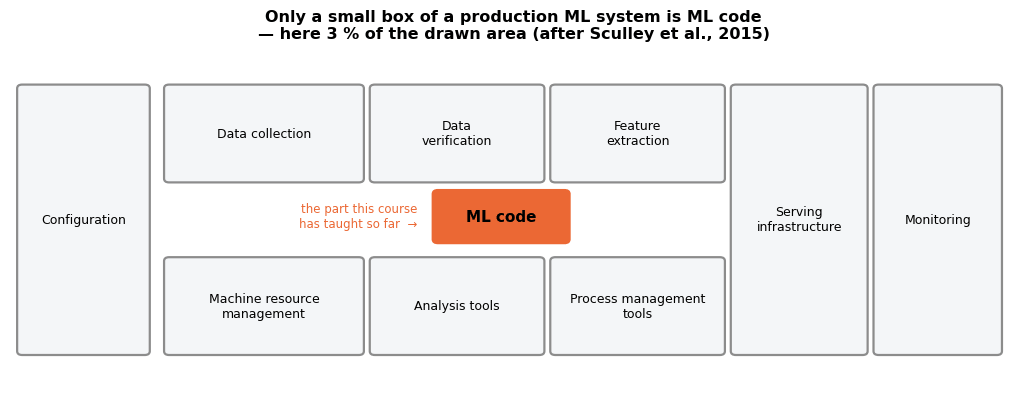

In [4]:
# (label, x, y, width, height) of each box that surrounds the ML code, laid out after Sculley et al.'s figure
surround = [
    ("Configuration", 0.1, 0.8, 1.55, 4.2), ("Data collection", 1.85, 3.5, 2.35, 1.5),
    ("Data\nverification", 4.3, 3.5, 2.05, 1.5), ("Feature\nextraction", 6.45, 3.5, 2.05, 1.5),
    ("Machine resource\nmanagement", 1.85, 0.8, 2.35, 1.5), ("Analysis tools", 4.3, 0.8, 2.05, 1.5),
    ("Process management\ntools", 6.45, 0.8, 2.05, 1.5), ("Serving\ninfrastructure", 8.6, 0.8, 1.6, 4.2),
    ("Monitoring", 10.3, 0.8, 1.5, 4.2),
]
fig, ax = plt.subplots(figsize=(13, 4.4))
blank_axes(ax, (0, 12), (0.3, 5.6))
for name, x, y, w_, h_ in surround:           # w_, h_: names distinct from the w, h of the previous cell
    box(ax, x, y, w_, h_, name, ec="0.55", fc="#f4f6f8", fontsize=9)
box(ax, 5.05, 2.55, 1.6, 0.8, "ML code", ec=PALETTE[1], fc=PALETTE[1], fontsize=11, weight="bold")
ax.text(4.85, 2.95, "the part this course\nhas taught so far  →", ha="right", va="center",
        fontsize=8.5, color=PALETTE[1])
# area of the 1.6 x 0.8 "ML code" box as a percentage of the total area of the surrounding boxes;
# the _ entries skip the label, x and y of each tuple
area = 1.6 * 0.8 / sum(w_ * h_ for _, _, _, w_, h_ in surround) * 100
# two adjacent string literals (a plain one and an f-string) are joined into one title
ax.set_title("Only a small box of a production ML system is ML code\n"
             f"— here {area:.0f} % of the drawn area (after Sculley et al., 2015)", fontsize=11.5)
plt.show()

The paper's real contribution is a *taxonomy of the debts* that this surrounding machinery
accumulates. The ones you will meet first:

- **CACE — "changing anything changes everything".** ML models have no clean interfaces:
  change one input feature and every learned weight changes. There is no such thing as a local
  change in a model.
- **Entanglement and undeclared consumers.** Someone reads your model's output from a table
  and builds a business rule on it. You improve the model; their rule breaks. Outputs need
  contracts as much as inputs do.
- **Data dependencies are more costly than code dependencies**, and unlike code dependencies
  the compiler cannot find them. An upstream team changes a currency unit or a category
  spelling and your model silently degrades. *Unstable* data dependencies (another model's
  output) and *underutilised* ones (features that earn nothing but must be maintained) are both
  liabilities.
- **Glue code and pipeline jungles.** The 5 % of code that is ML gets wrapped in 95 % of code
  that moves data around; scrapes and joins accrete until no one can reproduce a training set.
- **Configuration debt.** Dozens of flags, half of them stale, none of them reviewed.
- **Feedback loops.** The model influences the data it will be retrained on (a retention
  campaign changes who churns). Direct loops are bad; *hidden* loops through two models in the
  same product are worse.

> **Key idea.** Debt is not the cost of doing something; it is the interest you pay later
> because of how you did it. Every shortcut in this notebook's subject area — a feature
> re-implemented in the serving code, a model saved without metadata, a threshold hard-coded
> in three places — is a loan.

### 1.3 The ML test score

Breck et al. (2017) turned that diagnosis into a checklist. They propose 28 tests in four
areas — **features and data**, **model development**, **ML infrastructure**, and
**monitoring** — and a scoring rule: each test scores 0 if it is not done, 0.5 if it is done
manually, 1 if it is automated and repeated. The overall score is the **minimum** of the four
area totals, which is the point of the rubric: a system is only as production-ready as its
weakest area. A score of 0 means "more of a research project than a production system"; the
authors read scores above 3 as strong automated testing appropriate for critical systems.

Let us score the churn project as it stands at the end of notebook 12, and again as it will
stand at the end of *this* notebook. The four lists below are a paraphrased subset — read the
paper for all 28.

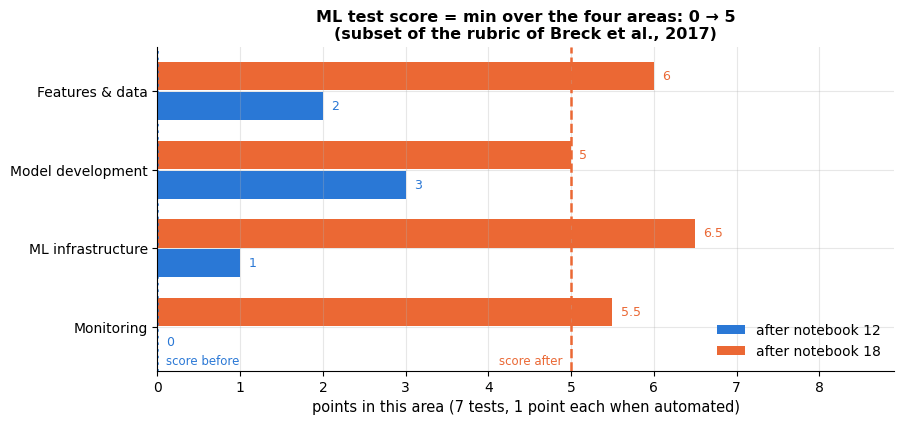

The weakest area is what the score reports — here Model development after this notebook.


In [5]:
checks = {                       # (test, score before this notebook, score after)
    "Features & data": [("feature expectations captured in a schema", 0, 1),
                        ("no unnecessary / leaking features", 1, 1),
                        ("features cost less than they are worth", 0.5, 0.5),
                        ("data pipeline has tests", 0, 1),
                        ("the training data are versioned / hashed", 0, 1),
                        ("privacy controls are documented", 0, 0.5),
                        ("a new feature can be added quickly", 0.5, 1)],
    "Model development": [("model specification is reviewed and in version control", 0, 1),
                          ("offline and online metrics correlate", 0, 0),
                          ("hyper-parameters were tuned", 1, 1),
                          ("model staleness is known", 0, 0.5),
                          ("a simpler model is not better", 1, 1),
                          ("quality is checked on data slices", 0.5, 1),
                          ("the model is tested for inclusion / fairness", 0.5, 0.5)],
    "ML infrastructure": [("training is reproducible", 0.5, 1),
                          ("model specification is unit-tested", 0, 1),
                          ("the full pipeline is integration-tested", 0, 1),
                          ("model quality is validated before serving", 0, 1),
                          ("the model allows debugging of single predictions", 0.5, 1),
                          ("models can be rolled back", 0, 0.5),
                          ("training and serving share the feature code", 0, 1)],
    "Monitoring": [("dependency changes are notified", 0, 0),
                   ("input distributions are monitored", 0, 1),
                   ("training and serving features are compared", 0, 1),
                   ("model staleness / age is monitored", 0, 0.5),
                   ("numerical stability (NaNs, infinities) is checked", 0, 1),
                   ("computational performance (latency) is monitored", 0, 1),
                   ("predictive quality is monitored on served data", 0, 1)],
}
# the dict comprehension builds {area: {"before": total, "after": total}}: sum(c[1] ...) adds the "before" scores of
# the area's 7 tests, sum(c[2] ...) the "after" scores. The areas become columns, so .T makes them rows: shape (4, 2)
scores = pd.DataFrame({area: {"before": sum(c[1] for c in items), "after": sum(c[2] for c in items)}
                       for area, items in checks.items()}).T
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ypos = np.arange(len(scores))                 # one y position per area: 0, 1, 2, 3
# two thin bars per area, shifted up and down by 0.19 so that they sit side by side
ax.barh(ypos + 0.19, scores["before"], height=0.36, color=PALETTE[0], label="after notebook 12")
ax.barh(ypos - 0.19, scores["after"], height=0.36, color=PALETTE[1], label="after notebook 18")
for i, (b, a) in enumerate(zip(scores["before"], scores["after"])):
    ax.text(b + 0.1, i + 0.19, f"{b:g}", va="center", fontsize=9, color=PALETTE[0])   # :g drops trailing zeros (3.0 -> 3)
    ax.text(a + 0.1, i - 0.19, f"{a:g}", va="center", fontsize=9, color=PALETTE[1])
# the score is the MINIMUM over the four areas: one vertical line at the minimum before, one at the minimum after
ax.axvline(scores["before"].min(), color=PALETTE[0], ls=":", lw=1.8)
ax.axvline(scores["after"].min(), color=PALETTE[1], ls="--", lw=1.8)
# xycoords=("data", "axes fraction"): x in data units, y as a fraction of the panel height (0.02 = near the bottom)
ax.annotate("score after", xy=(scores["after"].min() - 0.1, 0.02), xycoords=("data", "axes fraction"),
            ha="right", fontsize=8.5, color=PALETTE[1])
ax.annotate("score before", xy=(scores["before"].min() + 0.1, 0.02), xycoords=("data", "axes fraction"),
            ha="left", fontsize=8.5, color=PALETTE[0])
ax.set_yticks(ypos, scores.index)             # tick positions and their labels (the area names)
ax.invert_yaxis()                             # first area at the top
ax.set_xlabel("points in this area (7 tests, 1 point each when automated)")
ax.set_xlim(0, 8.9)
ax.set_title(f"ML test score = min over the four areas: {scores['before'].min():g} → {scores['after'].min():g}\n"
             "(subset of the rubric of Breck et al., 2017)", fontsize=11.5)
ax.legend(loc="lower right")
plt.show()
# .idxmin() returns the index label (here the area name) of the smallest value
print("The weakest area is what the score reports — here", scores["after"].idxmin(), "after this notebook.")

The jump is not from being clever; it is from writing down things that were previously implicit.

### 1.4 A project layout

Notebooks are excellent for exploration and terrible as a unit of software: they have hidden
state, they diff badly, and they cannot be imported. The standard cure is a small package
next to the notebooks, with notebooks reduced to narrative and figures.

```text
churn-project/
├── README.md                  what the model does, how to run it, who owns it
├── environment.yml            pinned dependencies (conda) + requirements.lock
├── config/
│   └── churn.yaml             paths, seed, hyper-parameters, thresholds
├── data/                      never in git: raw/, interim/, processed/ (DVC-tracked)
├── src/churn/
│   ├── data.py                loading and cleaning
│   ├── features.py            feature functions  <- shared by training AND serving
│   ├── model.py               make_model(), train(), evaluate()
│   ├── persist.py             save_model() / load_model()
│   ├── serve.py               the prediction service
│   └── monitor.py             drift metrics
├── tests/                     pytest: unit, schema, behavioural, integration
├── scripts/                   train.py, score_batch.py  (thin argparse wrappers)
├── notebooks/                 exploration and reports, stripped of outputs
└── artifacts/                 models, metrics, model cards (versioned, not in git)
```

Only two rules matter. **(1) Anything used at prediction time lives in an importable module.**
**(2) Notebooks import that module; they never redefine it.** Everything else — `src/` layout,
cookiecutter templates, a monorepo — is a matter of taste.

## 2. The notebook → module transition

Let us do exactly that with the churn pipeline designed in notebook 4. The cell below *writes a
Python module to disk* and the next cell imports it. This is the concrete moment when code
stops being a notebook cell and becomes a dependency — a shared definition that the training
script, the batch scorer, the web service and the tests all use.

In [6]:
# MODULE_SOURCE is the complete text of a Python file, held in one triple-quoted string; the end of this cell
# writes it to artifacts/churn_pipeline.py. Everything inside the string is file content, so the module is
# explained here instead:
#   logger           logging.getLogger(__name__) is a logger named after the module, "churn_pipeline"
#   DATA_PATH        Path(__file__) is the module's own file; .parents[2] is two folders further up than the folder
#                    it is in (artifacts -> notebooks -> repository root), so the CSV is found from anywhere
#   RAW_COLUMNS, NUMERIC, BINARY, CATEGORICAL, TARGET   the input columns, grouped by the preprocessing they get
#   load_raw(path)   read the raw CSV (DATA_PATH when no path is given)
#   clean(df)        drop duplicate customers, tidy the region spelling, set impossible charges (> 200) to NaN
#   add_features(df) return a copy with three new columns: new_customer (tenure < 6), tickets_x_charges and
#                    total_charges_missing
#   make_model(estimator, numeric)   build the unfitted Pipeline add_features -> ColumnTransformer -> classifier.
#                    FunctionTransformer wraps a plain function as a pipeline step; ColumnTransformer gives each
#                    list of columns its own preprocessing (median imputation + scaling, passthrough, one-hot;
#                    handle_unknown="ignore" encodes an unseen category as all zeros instead of raising an error);
#                    set_output(transform="pandas") makes it return DataFrames with readable column names
#   train(X, y, ...) make_model(...) then .fit(X, y), writing two INFO messages to the logger
#   predict_proba(model, rows)   P(churn) for raw rows: selects the known raw columns, returns column 1
#                    (the probability of class 1, "churned") of the classifier's predict_proba
MODULE_SOURCE = '''"""churn_pipeline.py — the churn model, as importable code.

Written by notebook 18 from the design of notebook 4.  It deliberately depends only on
numpy / pandas / scikit-learn so that it can be imported by a training job, a batch scorer,
a web service or a test suite without dragging in the course helpers.
"""
from __future__ import annotations

import logging
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

logger = logging.getLogger(__name__)

DATA_PATH = Path(__file__).resolve().parents[2] / "data" / "customer_churn.csv"

RAW_COLUMNS = ["customer_id", "signup_date", "region", "senior_citizen", "has_partner",
               "tenure_months", "contract", "payment_method", "internet_service",
               "tech_support", "streaming", "monthly_charges", "total_charges", "support_tickets"]
NUMERIC = ["tenure_months", "monthly_charges", "total_charges", "support_tickets", "tickets_x_charges"]
BINARY = ["senior_citizen", "has_partner", "tech_support", "streaming", "new_customer",
          "total_charges_missing"]
CATEGORICAL = ["contract", "payment_method", "internet_service", "region"]
TARGET = "churned"


def load_raw(path: Path | str | None = None) -> pd.DataFrame:
    """Read the raw churn export exactly as it is delivered."""
    return pd.read_csv(path or DATA_PATH)


def clean(df: pd.DataFrame) -> pd.DataFrame:
    """Row-level cleaning (notebook 4).  Changes the number of rows, so it cannot be a transformer."""
    out = df.drop_duplicates(subset="customer_id").copy()
    out["region"] = out["region"].str.strip().str.title()
    out.loc[out["monthly_charges"] > 200, "monthly_charges"] = np.nan
    return out.reset_index(drop=True)


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    """Stateless, row-wise feature construction — the ONE definition used by training and serving."""
    out = df.copy()
    out["signup_date"] = pd.to_datetime(out["signup_date"])
    return out.assign(
        new_customer=(out["tenure_months"] < 6).astype(int),
        tickets_x_charges=out["support_tickets"] * out["monthly_charges"],
        total_charges_missing=out["total_charges"].isna().astype(int),
    )


def make_model(estimator=None, numeric: list[str] | None = None) -> Pipeline:
    """Raw customer rows in, churn probability out: features + preprocessing + classifier."""
    numeric = list(NUMERIC if numeric is None else numeric)
    preprocess = ColumnTransformer(
        [("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                           ("scale", StandardScaler())]), numeric),
         ("bin", "passthrough", BINARY),
         ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL)],
        verbose_feature_names_out=False).set_output(transform="pandas")
    return Pipeline([("features", FunctionTransformer(add_features)),
                     ("prep", preprocess),
                     ("model", estimator if estimator is not None else LogisticRegression(max_iter=1000))])


def train(X: pd.DataFrame, y: pd.Series, estimator=None, numeric: list[str] | None = None) -> Pipeline:
    """Fit the pipeline and log what was fitted (logging, not printing: the caller chooses the sink)."""
    model = make_model(estimator, numeric)
    logger.info("training on %d rows, %d raw columns, churn rate %.3f", len(X), X.shape[1], float(y.mean()))
    model.fit(X, y)
    logger.info("fitted %s", model.named_steps["model"].__class__.__name__)
    return model


def predict_proba(model: Pipeline, rows: pd.DataFrame) -> np.ndarray:
    """Churn probability for raw customer rows (the only supported prediction entry point)."""
    return model.predict_proba(rows[[c for c in RAW_COLUMNS if c in rows.columns]])[:, 1]
'''

module_path = ARTIFACTS / "churn_pipeline.py"
module_path.write_text(MODULE_SOURCE)             # write the string to the file (creates or overwrites it)
# .splitlines() splits the text into a list of lines; .stat().st_size is the file size in bytes
print(f"wrote {module_path} ({len(MODULE_SOURCE.splitlines())} lines, "
      f"{module_path.stat().st_size / 1024:.1f} KB)")

wrote artifacts/churn_pipeline.py (83 lines, 3.9 KB)


Now import it. Adding `artifacts/` to `sys.path` imitates an installed package (`pip install -e .`
is what you would really do); `importlib.invalidate_caches()` makes Python notice a file that
was created after the interpreter started.

In [7]:
# sys.path is the list of folders Python searches on import: put artifacts/ first so churn_pipeline.py is found
if str(ARTIFACTS.resolve()) not in sys.path:     # the check avoids adding it again when the cell is re-run
    sys.path.insert(0, str(ARTIFACTS.resolve()))
importlib.invalidate_caches()
import churn_pipeline as cp                      # noqa: E402  (the module was written above)
cp = importlib.reload(cp)                        # pick up edits when this notebook is re-run

churn = cp.clean(cp.load_raw())                  # the module's own loading and cleaning
X = churn[cp.RAW_COLUMNS]                        # the 14 raw input columns
y = churn[cp.TARGET]                             # the 0/1 target column "churned"
# hold out 20 % as a test set; stratify=y keeps the churn rate the same in both parts
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
# (the comparison with course_utils.load_churn() checks the number of rows only)
print(f"module version of the data: {churn.shape[0]} rows; "
      f"identical to course_utils.load_churn(): {len(churn) == len(load_churn())}")
print(f"train {X_train.shape} | test {X_test.shape} | churn rate {y_train.mean():.3f}")
X_train.head(3)

module version of the data: 5000 rows; identical to course_utils.load_churn(): True
train (4000, 14) | test (1000, 14) | churn rate 0.327


,customer_id,signup_date,region,senior_citizen,has_partner,tenure_months,contract,payment_method,internet_service,tech_support,streaming,monthly_charges,total_charges,support_tickets
1776,C01777,2022-05-22,East,1,0,25,One year,Electronic check,DSL,0,0,52.11,1302.81,0
2096,C02097,2021-08-22,North,0,0,34,Month-to-month,Mailed check,Fiber optic,0,0,90.61,3065.28,4
3518,C03519,2024-01-17,West,0,1,5,Month-to-month,Mailed check,Fiber optic,0,0,89.12,NaN,2


Routing all messages through `logging` rather than `print` is the other half of the move. A
library must not decide where its output goes; the *application* attaches a handler — a file
here, `stdout` in a container, a log aggregator in production.

In [8]:
log_path = ARTIFACTS / "training.log"
# getLogger(name) always returns the same logger for the same name: this is the logger the module created
logger = logging.getLogger("churn_pipeline")
logger.setLevel(logging.INFO)            # let INFO messages through (by default only WARNING and above pass)
logger.handlers.clear()                  # drop handlers from earlier runs of this cell, so lines are not duplicated
handler = logging.FileHandler(log_path, mode="w")     # a handler sends messages somewhere: here to a file, overwritten
# the layout of each line: style="{" uses str.format fields, {levelname:<7} left-aligns the level in 7 characters,
# datefmt formats {asctime} as hours:minutes:seconds
handler.setFormatter(logging.Formatter(fmt="{asctime} {levelname:<7} {name}: {message}",
                                       style="{", datefmt="%H:%M:%S"))
logger.addHandler(handler)

model_v1 = cp.train(X_train, y_train)            # the module logs; the notebook decides where
handler.flush()                                  # make sure everything buffered has reached the file
print(log_path.read_text().strip())
p_test = cp.predict_proba(model_v1, X_test)      # P(churn) for every test customer, shape (1000,)
print(f"\nheld-out ROC-AUC {roc_auc_score(y_test, p_test):.4f} | "
      f"average precision {average_precision_score(y_test, p_test):.4f} | "
      f"Brier score {brier_score_loss(y_test, p_test):.4f}")

09:18:37 INFO    churn_pipeline: training on 4000 rows, 14 raw columns, churn rate 0.327
09:18:37 INFO    churn_pipeline: fitted LogisticRegression

held-out ROC-AUC 0.8330 | average precision 0.7243 | Brier score 0.1512


The object we just fitted is *one* estimator that goes from a raw customer row to a
probability. That matters enormously later: there is no preprocessing step outside it that a
serving engineer could get wrong.

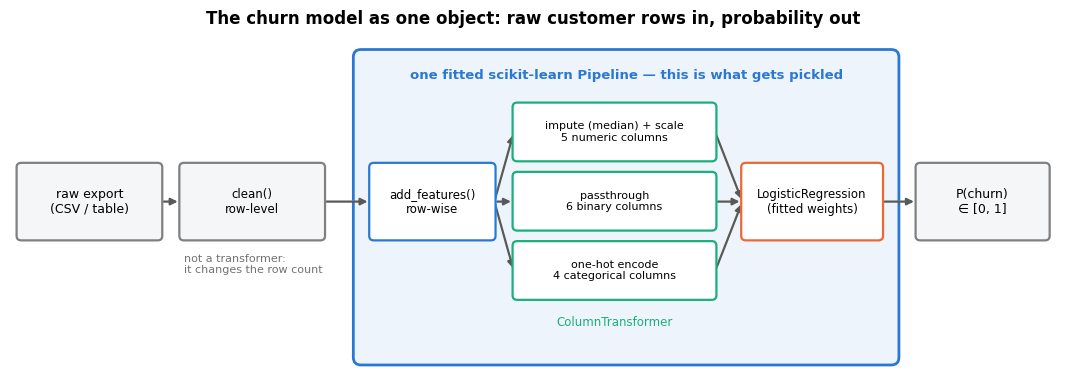

In [9]:
fig, ax = plt.subplots(figsize=(13.5, 4.4))
blank_axes(ax, (0, 13.5), (0.25, 4.75))
box(ax, 0.1, 2.0, 1.85, 1.0, "raw export\n(CSV / table)", ec="0.5", fc="#f4f6f8")
box(ax, 2.2, 2.0, 1.85, 1.0, "clean()\nrow-level", ec="0.5", fc="#f4f6f8", fontsize=8.5)
# a large rounded rectangle behind the steps (zorder=0) that groups everything inside the Pipeline
ax.add_patch(FancyBboxPatch((4.45, 0.35), 7.0, 4.15, boxstyle="round,pad=0.02,rounding_size=0.1",
                            facecolor="#eef4fb", edgecolor=PALETTE[0], linewidth=2.0, zorder=0))
ax.text(7.95, 4.18, "one fitted scikit-learn Pipeline — this is what gets pickled",
        ha="center", va="center", fontsize=9.5, color=PALETTE[0], weight="semibold")
box(ax, 4.65, 2.0, 1.6, 1.0, "add_features()\nrow-wise", ec=PALETTE[0], fontsize=8.5)
# the three branches of the ColumnTransformer, stacked vertically
box(ax, 6.5, 3.05, 2.6, 0.75, "impute (median) + scale\n5 numeric columns", ec=PALETTE[2], fontsize=8)
box(ax, 6.5, 2.13, 2.6, 0.75, "passthrough\n6 binary columns", ec=PALETTE[2], fontsize=8)
box(ax, 6.5, 1.21, 2.6, 0.75, "one-hot encode\n4 categorical columns", ec=PALETTE[2], fontsize=8)
ax.text(7.8, 0.85, "ColumnTransformer", ha="center", fontsize=8.5, color=PALETTE[2])
box(ax, 9.45, 2.0, 1.8, 1.0, "LogisticRegression\n(fitted weights)", ec=PALETTE[1], fontsize=8.5)
box(ax, 11.7, 2.0, 1.7, 1.0, "P(churn)\n∈ [0, 1]", ec="0.5", fc="#f4f6f8")
arrow(ax, (1.95, 2.5), (2.2, 2.5))
arrow(ax, (4.05, 2.5), (4.65, 2.5))
for y_ in (3.42, 2.5, 1.58):                 # fan out to each branch, then back in to the classifier
    arrow(ax, (6.25, 2.5), (6.5, y_), rad=0.0)
    arrow(ax, (9.1, y_), (9.45, 2.5), rad=0.0)
arrow(ax, (11.25, 2.5), (11.7, 2.5))
ax.text(2.25, 1.55, "not a transformer:\nit changes the row count", fontsize=8, color="0.45")
ax.set_title("The churn model as one object: raw customer rows in, probability out", fontsize=12)
plt.show()

> **Warning — the cleaning step is deliberately outside the estimator.** `clean()` drops
> duplicate customers, so it changes the number of rows. A scikit-learn transformer must return
> one output row per input row (otherwise `X` and `y` fall out of alignment), so row-level
> cleaning belongs in the data pipeline, before the estimator. Row-*wise* feature construction
> (`add_features`) belongs inside it, where serving cannot forget to call it.

## 3. Reproducibility and experiment tracking

### 3.1 What "reproducible" means

Pineau et al. (2021) distinguish *reproducibility* (someone else, same data and code, gets the
same result) from *replicability* (a different experiment supports the same conclusion). Only
the first is an engineering problem, and it needs four things pinned:

1. **Code** — a commit hash. In a notebook, that means the notebook plus the module it imports.
2. **Data** — a content hash, not a file name. `customers.csv` is not a version.
3. **Environment** — exact library versions. scikit-learn changes defaults between minor
   releases; NumPy changed its random-number API.
4. **Randomness** — every seed, passed explicitly (`random_state=`, a `Generator`), never
   global state.

Sandve et al. (2013) and Wilson et al. (2014) give the wider "rules for reproducible research"
version of the same list, and both make the point that the cheapest step is to record
*everything automatically*, because anything that relies on discipline eventually fails.

In [10]:
def file_sha256(path: Path, chunk: int = 1 << 20) -> str:
    """Hash a file's bytes — this is what DVC and git-lfs track, and it survives copying.

    The file is read in blocks of `chunk` bytes (1 << 20 = 2**20 bytes = 1 MiB), so even a huge file never has to
    fit in memory. Returns the SHA-256 digest as a 64-character hexadecimal string.
    """
    h = hashlib.sha256()                     # an incremental SHA-256 hasher
    with open(path, "rb") as f:              # "rb": read raw bytes, not text
        # iter(fn, sentinel) calls fn() until it returns the sentinel: f.read(chunk) until b"" (the end of the file)
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)                  # feeding blocks one by one gives the same hash as the whole file at once
    return h.hexdigest()                     # the digest as hexadecimal text


def frame_hash(df: pd.DataFrame) -> str:
    """Hash the *content* of a DataFrame (order-sensitive, index included).

    Returns a 64-character hex string; changing any value, the row order or the index gives a different hash.
    """
    # hash_pandas_object gives one 64-bit hash per row (index=True includes the row label in it);
    # .to_numpy().tobytes() turns those numbers into raw bytes, which SHA-256 condenses into one fingerprint
    return hashlib.sha256(pd.util.hash_pandas_object(df, index=True).to_numpy().tobytes()).hexdigest()


def git_revision(default: str = "no-git-repo") -> str:
    """Short commit hash of the working tree, or a placeholder when there is no repository.

    Runs `git rev-parse --short HEAD` (the abbreviated id of the current commit); any failure, such as git not
    being installed, no repository or a timeout, returns `default` instead.
    """
    try:
        # capture_output=True collects stdout / stderr instead of printing them, text=True decodes them to str,
        # timeout=5 gives up after 5 seconds, check=True raises an exception if git exits with an error
        out = subprocess.run(["git", "rev-parse", "--short", "HEAD"],
                             capture_output=True, text=True, timeout=5, check=True)
        return out.stdout.strip()            # strip() removes the trailing newline
    except Exception:
        return default


data_hash = frame_hash(X_train)                  # the version identifier of the training data
perturbed = X_train.copy()
# .columns.get_loc(name) is the integer position of a column, so .iloc can address the cell (row 0, tenure_months)
perturbed.iloc[0, perturbed.columns.get_loc("tenure_months")] += 1
# [:16] prints only the first 16 hex characters, which is plenty to tell versions apart
print(f"training-data hash          {data_hash[:16]}")
print(f"after changing ONE cell     {frame_hash(perturbed)[:16]}   <- a different dataset")
print(f"raw CSV file hash           {file_sha256(cp.DATA_PATH)[:16]}")
print(f"code revision               {git_revision()}")
print(f"module hash                 {file_sha256(module_path)[:16]}")

training-data hash          3ef3c77f3de62b5f
after changing ONE cell     efef3160c2ccfe11   <- a different dataset
raw CSV file hash           7c554ef8093e1e26
code revision               no-git-repo
module hash                 a67512d2d89e8af8


> **Going deeper — data versioning.** DVC keeps a small text file (`data/churn.csv.dvc`)
> containing the content hash of a large file in git, and the file itself in object storage
> keyed by that hash. `git checkout` of an old commit plus `dvc checkout` restores exactly the
> data that commit was trained on. The idea is the one above — *a version is a hash* — wrapped
> in tooling that also handles remotes and caching. `lakeFS`, `Delta Lake` table versions and
> plain "write a new partition, never overwrite" conventions solve the same problem.

### 3.2 Configuration in a file, not in cells

Every number that a future run might want to change should be in one place, outside the code:
paths, the seed, model hyper-parameters, the decision threshold, drift alarm levels. YAML is
the usual choice because humans edit it.

In [11]:
import yaml          # PyYAML: reads and writes YAML, a human-friendly text format for nested settings

# every value a future run might want to change, grouped in nested dicts (they become YAML sections)
config = {
    "project": "churn-retention",
    "seed": RANDOM_STATE,
    # .name keeps only the file name of the path, without its folders
    "data": {"path": str(cp.DATA_PATH.name), "target": cp.TARGET, "test_size": 0.2},
    # C is the inverse regularisation strength of the logistic regression (smaller C = stronger penalty)
    "model": {"kind": "logistic_regression", "C": 1.0, "max_iter": 1000},
    # the probability above which a customer is contacted, and the latency budget of one request
    "serving": {"decision_threshold": 0.5, "max_latency_ms": 50},
    # PSI warning and alert levels (section 7) and the lowest acceptable ROC-AUC
    "monitoring": {"psi_warn": 0.10, "psi_alert": 0.25, "min_auc": 0.78},
}
config_path = ARTIFACTS / "churn_config.yaml"
# yaml.safe_dump turns the dict into YAML text; sort_keys=False keeps the keys in the order written above
config_path.write_text(yaml.safe_dump(config, sort_keys=False))
# yaml.safe_load parses YAML back into dicts, lists, numbers and strings (and never builds arbitrary Python objects)
loaded_config = yaml.safe_load(config_path.read_text())
print(config_path.read_text())
print("round-trip identical:", loaded_config == config)      # == on dicts compares every key and value, nested ones too

project: churn-retention
seed: 42
data:
  path: customer_churn.csv
  target: churned
  test_size: 0.2
model:
  kind: logistic_regression
  C: 1.0
  max_iter: 1000
serving:
  decision_threshold: 0.5
  max_latency_ms: 50
monitoring:
  psi_warn: 0.1
  psi_alert: 0.25
  min_auc: 0.78

round-trip identical: True


### 3.3 A minimal experiment tracker

An experiment tracker is, at its core, an append-only log of `(configuration, data version,
code version, metrics)` records plus a way to query them. Fifteen lines of JSON Lines give you
most of the value; the hosted tools add a UI, artefact storage, collaboration and system
metrics. Notebook 12 (*model selection and hyper-parameter tuning*) chose hyper-parameters with
`GridSearchCV`; here we log *why* the chosen configuration was chosen, so that the decision
survives the session.

In [12]:
RUNS_PATH = ARTIFACTS / "runs.jsonl"


def log_run(record: dict, path: Path = RUNS_PATH) -> str:
    """Append one immutable run record (JSON Lines: one self-contained JSON object per line).

    `record` is any JSON-serialisable dict (name, params, metrics, ...); a run id, a UTC timestamp and the code
    revision are added in front of its keys. Returns the new run id.
    """
    # run id = the UTC time plus a random suffix. {dt:%Y%m%dT%H%M%S} formats the datetime with strftime codes
    # (year, month, day, "T", hours, minutes, seconds); rng.integers(1 << 24) is a random integer below 2**24
    # and :06x writes it as 6 hexadecimal digits, padded with zeros
    run_id = f"{datetime.now(timezone.utc):%Y%m%dT%H%M%S}-{rng.integers(1 << 24):06x}"
    # {..., **record} builds a new dict: the three fields first, then every key-value pair of record
    record = {"run_id": run_id, "created_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
              "code_revision": git_revision(), **record}
    with open(path, "a") as f:                       # "a" = append to the end of the file, never overwrite
        f.write(json.dumps(record) + "\n")           # json.dumps: dict -> one line of JSON text
    return run_id


def load_runs(path: Path = RUNS_PATH) -> pd.DataFrame:
    """Read the log back as a flat table (nested keys become dotted columns).

    Returns one row per run; e.g. {"metrics": {"roc_auc": ...}} becomes a column "metrics.roc_auc".
    Returns an empty DataFrame when the log does not exist yet.
    """
    if not path.exists():
        return pd.DataFrame()
    # json.loads parses one line back into a dict; `if line.strip()` skips blank lines
    records = [json.loads(line) for line in path.read_text().splitlines() if line.strip()]
    return pd.json_normalize(records)                # flattens nested dicts into columns named "outer.inner"


RUNS_PATH.unlink(missing_ok=True)                # start from an empty log in this notebook
# run name -> (estimator, list of numeric columns to use; None means the module's default cp.NUMERIC)
candidates = {
    # C is the inverse regularisation strength: smaller C = a stronger L2 penalty on the weights
    "logreg C=0.1": (LogisticRegression(C=0.1, max_iter=1000), None),
    "logreg C=1": (LogisticRegression(C=1.0, max_iter=1000), None),
    "logreg C=10": (LogisticRegression(C=10.0, max_iter=1000), None),
    # a list comprehension with a condition: every numeric column except the raw support_tickets count
    "logreg C=1, no raw tickets": (LogisticRegression(C=1.0, max_iter=1000),
                                   [c for c in cp.NUMERIC if c != "support_tickets"]),
    # max_iter = number of boosting rounds (trees), max_depth limits each tree, learning_rate shrinks each tree's step
    "HGB depth 3": (HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_iter=60,
                                                   max_depth=3), None),
    "HGB depth 3, lr=0.05": (HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_iter=80,
                                                            learning_rate=0.05, max_depth=3), None),
}
# 3 folds that each keep the training set's churn rate; shuffle=True shuffles the rows before splitting them
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
for name, (estimator, numeric) in candidates.items():        # unpack the key and the (estimator, numeric) tuple
    # cross_validate fits a fresh copy of the pipeline on each training fold and scores it on the held-out fold, for
    # every metric in `scoring`; it returns a dict of arrays with one value per fold: test_roc_auc, ..., fit_time
    res = cross_validate(cp.make_model(estimator, numeric), X_train, y_train, cv=cv,
                         scoring=["roc_auc", "average_precision", "neg_brier_score"])
    log_run({"name": name, "data_hash": data_hash[:16], "n_train": len(X_train),
             "env": {"sklearn": sklearn.__version__, "numpy": np.__version__},
             "params": {"estimator": estimator.__class__.__name__,      # the class name, e.g. "LogisticRegression"
                        # get_params() returns every hyper-parameter; the dict comprehension keeps four of them
                        # and ** unpacks the result into this dict
                        **{k: v for k, v in estimator.get_params().items()
                           if k in {"C", "learning_rate", "max_iter", "max_depth"}},
                        "numeric_features": len(numeric) if numeric else len(cp.NUMERIC)},
             "metrics": {"roc_auc": res["test_roc_auc"].mean(),
                         # standard error of the mean over the folds: sample std (ddof=1) / sqrt(number of folds)
                         "roc_auc_se": res["test_roc_auc"].std(ddof=1) / np.sqrt(cv.get_n_splits()),
                         "average_precision": res["test_average_precision"].mean(),
                         # scikit-learn negates the Brier score so that higher is better; the minus undoes that
                         "brier": -res["test_neg_brier_score"].mean(),
                         "fit_seconds": res["fit_time"].mean()}})
runs = load_runs()                               # the whole log as a table, one row per run
print(f"{len(runs)} runs logged to {RUNS_PATH.name} ({RUNS_PATH.stat().st_size / 1024:.1f} KB)")
runs_view = runs[["name", "metrics.roc_auc", "metrics.roc_auc_se", "metrics.brier",
                  "metrics.fit_seconds"]].round(4)
runs_view.columns = ["run", "CV ROC-AUC", "± SE", "Brier", "fit (s)"]      # shorter names for display
runs_view

6 runs logged to runs.jsonl (3.1 KB)


,run,CV ROC-AUC,± SE,Brier,fit (s)
0,logreg C=0.1,0.8574,0.0104,0.1388,0.0228
1,logreg C=1,0.8579,0.0108,0.1385,0.0261
2,logreg C=10,0.8579,0.0109,0.1386,0.0234
3,"logreg C=1, no raw tickets",0.8578,0.0108,0.1387,0.0249
4,HGB depth 3,0.8539,0.0092,0.1401,0.0888
5,"HGB depth 3, lr=0.05",0.8535,0.0101,0.1407,0.0960


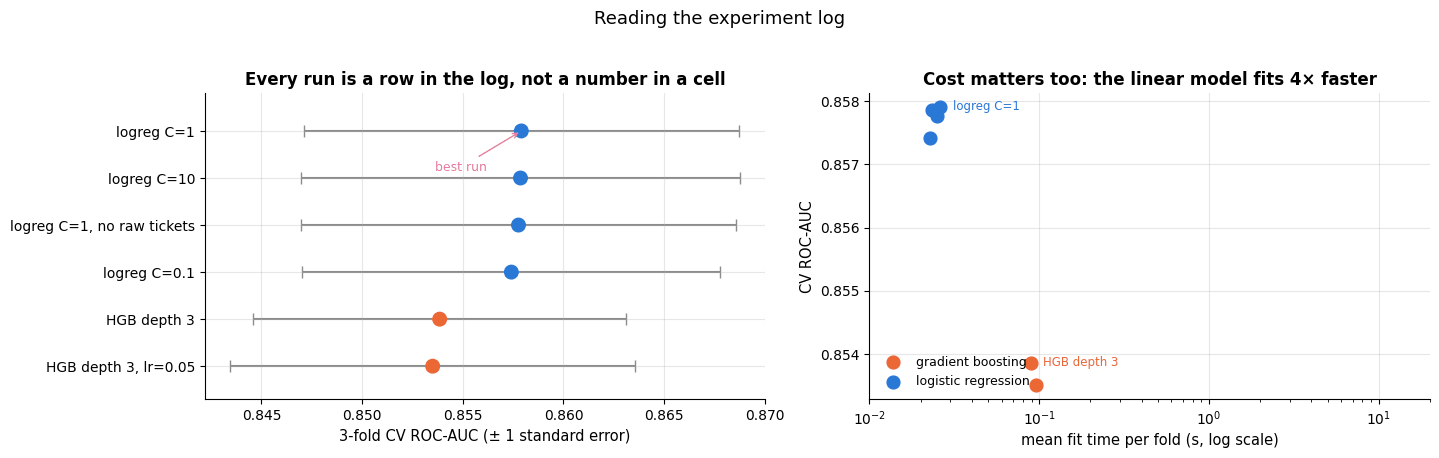

best run: logreg C=1  (run_id 20260919T071838-c621fb, data 3ef3c77f3de62b5f)
best minus best boosted model: +0.0041 ROC-AUC (standard error 0.0108)


In [13]:
is_hgb = runs["name"].str.startswith("HGB")       # boolean mask: True for the gradient-boosting runs
order = runs.sort_values("metrics.roc_auc").reset_index(drop=True)    # worst to best; drop=True discards the old index
best = runs.loc[runs["metrics.roc_auc"].idxmax()]      # idxmax: the index label of the top score -> that whole row
ypos = np.arange(len(order))
fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.4))
# left: one dot per run with a ± 1 standard-error bar; fmt="none" draws only the bars, xerr makes them horizontal
axes[0].errorbar(order["metrics.roc_auc"], ypos, xerr=order["metrics.roc_auc_se"], fmt="none",
                 ecolor="0.55", capsize=4, lw=1.5, zorder=1)
axes[0].scatter(order["metrics.roc_auc"], ypos, s=95, zorder=3,
                color=[PALETTE[1] if n.startswith("HGB") else PALETTE[0] for n in order["name"]])
axes[0].set_yticks(ypos, order["name"])
axes[0].set_ylim(-0.7, len(order) - 0.2)
axes[0].set_xlabel("3-fold CV ROC-AUC (± 1 standard error)")
axes[0].set_title("Every run is a row in the log, not a number in a cell")
# the best run is the last row of `order`; textcoords="offset points" makes xytext an offset (in points) from xy
axes[0].annotate("best run", xy=(best["metrics.roc_auc"], len(order) - 1), xytext=(-62, -26),
                 textcoords="offset points", va="center", color=PALETTE[4], fontsize=9,
                 arrowprops=dict(arrowstyle="->", color=PALETTE[4]))
# right: fit time against score, one colour per model family
for family, colour, label in [(True, PALETTE[1], "gradient boosting"), (False, PALETTE[0], "logistic regression")]:
    sub = runs[is_hgb == family]                          # the runs of this family
    axes[1].scatter(sub["metrics.fit_seconds"], sub["metrics.roc_auc"], s=85, color=colour,
                    label=label, zorder=3)
    top = sub.loc[sub["metrics.roc_auc"].idxmax()]        # the family's best run gets a name label
    axes[1].annotate(top["name"], (top["metrics.fit_seconds"], top["metrics.roc_auc"]),
                     textcoords="offset points", xytext=(9, -2), fontsize=8.5, color=colour)
axes[1].set_xscale("log")
axes[1].set_xlabel("mean fit time per fold (s, log scale)")
axes[1].set_ylabel("CV ROC-AUC")
axes[1].set_xlim(0.01, 20)
axes[1].legend(loc="lower left", fontsize=9)
# mean fit time of the boosted runs divided by that of the linear runs; ~ inverts a boolean mask
speedup = runs.loc[is_hgb, "metrics.fit_seconds"].mean() / runs.loc[~is_hgb, "metrics.fit_seconds"].mean()
axes[1].set_title(f"Cost matters too: the linear model fits {speedup:.0f}× faster")
fig.suptitle("Reading the experiment log", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()
print(f"best run: {best['name']}  (run_id {best['run_id']}, data {best['data_hash']})")
# :+.4f always prints the sign (+ or -) of the difference
print(f"best minus best boosted model: "
      f"{best['metrics.roc_auc'] - runs.loc[is_hgb, 'metrics.roc_auc'].max():+.4f} ROC-AUC "
      f"(standard error {best['metrics.roc_auc_se']:.4f})")

On this dataset the regularised linear model is not beaten by the boosted trees. "Not beaten"
is the honest phrasing: the gap is smaller than the standard error of the estimate, so the two
families are tied, and the engineered interaction feature — built in notebook 4 — gives the
linear model most of what the trees would otherwise have to discover for themselves. The four
logistic-regression runs are tied with one another too, so we keep the module's default
`C = 1` and record that this was a coin-flip rather than a finding. The *log* is what lets you
say all of this six months later, with a run id and a data hash attached.

> **Key idea — the best CV score is not automatically what you ship.** Serving cost, latency,
> monotonic behaviour (section 5.3) and debuggability are release criteria too. Here they all
> point the same way, so we deploy the linear model; when they point the other way, write down
> which criterion won and why, because that decision is the one people will question in six
> months.

```py
# The same idea with MLflow, once you have a tracking server:
import mlflow
mlflow.set_experiment("churn-retention")
with mlflow.start_run(run_name="logreg C=1"):
    mlflow.log_params({"C": 1.0, "numeric_features": 5})
    mlflow.log_metrics({"roc_auc": 0.8330, "brier": 0.1512})
    mlflow.sklearn.log_model(model, name="model")          # stores the artefact + environment
# Weights & Biases (wandb.init / wandb.log / wandb.log_artifact) has the same shape.
```

## 4. Persisting a model with its metadata

### 4.1 A pickle is not a model

`joblib.dump` (a `pickle` specialisation that stores large NumPy arrays efficiently) writes
the *object graph* of the fitted pipeline. Two consequences you must internalise:

> **Warning — pickle is code execution.** Loading a pickle can run arbitrary Python. Never
> unpickle a file you did not produce or cannot verify. Treat model files like executables:
> restricted storage, access control, integrity checks, and — in a real registry — signatures.
> `skops` exists precisely to serialise scikit-learn models without arbitrary code execution,
> and ONNX exports a *computational graph* that a runtime without Python can execute.

> **Warning — version coupling.** The pickle stores references to classes by module path, not
> the code itself. Load it with a different scikit-learn version and you may get a warning, a
> subtly different object, or an exception; load it without `churn_pipeline` importable and
> `FunctionTransformer(add_features)` cannot be reconstructed at all. The environment is part
> of the model.

A model artefact is therefore never a single file. It is a *bundle*: the serialised estimator
plus metadata that lets you decide whether loading it is safe and whether its predictions can
be trusted.

In [14]:
import joblib        # pickle-based saving and loading, efficient for objects that contain large NumPy arrays

MODEL_DIR = ARTIFACTS / "models"


def save_model(model, name: str, version: str, *, metrics: dict, features: list[str],
               data_hash: str, threshold: float, notes: str = "", directory: Path = MODEL_DIR) -> dict:
    """Write <name>_<version>.joblib plus a JSON sidecar describing how it was produced.

    model       the fitted Pipeline (its last step, "model", is the classifier)
    metrics     held-out metrics to record; features: the raw input columns the model expects
    data_hash   fingerprint of the training data; threshold: the decision threshold to serve with
    notes       free text, e.g. why this version exists
    Also logs a "register" run in the experiment log. Returns the metadata dict written to <name>_<version>.json.
    """
    directory.mkdir(parents=True, exist_ok=True)
    model_path = directory / f"{name}_{version}.joblib"
    joblib.dump(model, model_path)                   # serialise the whole fitted pipeline into one file
    meta = {
        "name": name, "version": version,
        "created_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        # register the model in the experiment log too, and keep that run's id: it links the model to the log
        "run_id": log_run({"name": f"register {name}_{version}", "metrics": metrics,
                           "data_hash": data_hash, "params": {"threshold": threshold}}),
        "code_revision": git_revision(), "module_sha256": file_sha256(module_path)[:16],    # the code version
        # sys.version is a long string like "3.11.15 (main, ...)"; .split()[0] keeps only the version number
        "environment": {"python": sys.version.split()[0], "scikit-learn": sklearn.__version__,
                        "numpy": np.__version__, "pandas": pd.__version__, "joblib": joblib.__version__},
        "data_hash": data_hash, "input_features": features, "target": cp.TARGET,
        "estimator": model.named_steps["model"].__class__.__name__,    # named_steps: a pipeline's steps by name
        # a few hyper-parameters, as strings so that json can store any value
        "params": {k: str(v) for k, v in model.named_steps["model"].get_params().items()
                   if k in {"C", "max_iter", "learning_rate", "max_depth", "random_state"}},
        # float() makes every value a plain Python float (json cannot write NumPy integers): hence n_train 4000.0
        "metrics": {k: round(float(v), 4) for k, v in metrics.items()},
        "decision_threshold": threshold, "notes": notes,
        # size and hash of the .joblib file, so that load_model can detect a modified or corrupted file
        "artifact": {"file": model_path.name, "bytes": model_path.stat().st_size,
                     "sha256": file_sha256(model_path)[:16]},
    }
    # the JSON sidecar next to the model file; indent=2 pretty-prints it over several lines
    (directory / f"{name}_{version}.json").write_text(json.dumps(meta, indent=2))
    return meta


def load_model(name: str, version: str, *, strict: bool = False, directory: Path = MODEL_DIR):
    """Load a bundle, verifying integrity and environment compatibility before returning it.

    Raises OSError if the .joblib file's hash differs from the one in its metadata. If the model was trained with
    another scikit-learn version it prints a warning, or raises RuntimeError when strict=True.
    Returns the tuple (fitted model, metadata dict).
    """
    model_path = directory / f"{name}_{version}.joblib"
    meta = json.loads((directory / f"{name}_{version}.json").read_text())    # read the sidecar first
    if file_sha256(model_path)[:16] != meta["artifact"]["sha256"]:           # 1. integrity check
        raise OSError(f"{model_path.name} does not match the hash recorded in its metadata")
    trained_with = meta["environment"]["scikit-learn"]
    if trained_with != sklearn.__version__:                                  # 2. version check
        # adjacent strings inside parentheses are joined into one string
        message = (f"model was trained with scikit-learn {trained_with}, "
                   f"this environment has {sklearn.__version__}")
        if strict:
            raise RuntimeError(message)
        print(f"[load_model] WARNING: {message} — predictions may differ; re-validate before serving.")
    return joblib.load(model_path), meta             # 3. unpickle, only after both checks


# register the baseline v1 together with its held-out test metrics
meta_v1 = save_model(model_v1, "churn", "v1", features=cp.RAW_COLUMNS, data_hash=data_hash,
                     threshold=config["serving"]["decision_threshold"],
                     notes="Baseline: notebook 4 feature set, logistic regression.",
                     metrics={"roc_auc": roc_auc_score(y_test, p_test),
                              "average_precision": average_precision_score(y_test, p_test),
                              "brier": brier_score_loss(y_test, p_test),
                              "n_train": len(X_train), "n_test": len(X_test)})
# a selection of the metadata keys, pretty-printed; [:900] keeps at most the first 900 characters
print(json.dumps({k: meta_v1[k] for k in ["name", "version", "created_at", "environment",
                                          "data_hash", "metrics", "artifact"]}, indent=2)[:900])

{
  "name": "churn",
  "version": "v1",
  "created_at": "2026-09-19T07:18:39+00:00",
  "environment": {
    "python": "3.11.15",
    "scikit-learn": "1.8.0",
    "numpy": "2.4.4",
    "pandas": "3.0.2",
    "joblib": "1.5.3"
  },
  "data_hash": "3ef3c77f3de62b5f077e7ac60d9df8a92ceb59f8f1c5696daa416d45f825ae0d",
  "metrics": {
    "roc_auc": 0.833,
    "average_precision": 0.7243,
    "brier": 0.1512,
    "n_train": 4000.0,
    "n_test": 1000.0
  },
  "artifact": {
    "file": "churn_v1.joblib",
    "bytes": 7402,
    "sha256": "506a4c3f7530b2f5"
  }
}


In [15]:
reloaded, meta = load_model("churn", "v1")
same = np.allclose(cp.predict_proba(reloaded, X_test), p_test)     # the reloaded model must give the same scores
print(f"round-trip predictions identical: {same}")

# What happens when the environment has moved on?  Simulate it by editing the sidecar.
faked = json.loads((MODEL_DIR / "churn_v1.json").read_text())
faked["environment"]["scikit-learn"] = "1.3.2"                  # pretend v1 was trained with an old version
(MODEL_DIR / "churn_v1_stale.json").write_text(json.dumps(faked))
joblib.dump(model_v1, MODEL_DIR / "churn_v1_stale.joblib")      # a copy of the model under the fake version name
# record the copy's real hash, so that the integrity check passes and only the version check fires
faked["artifact"]["sha256"] = file_sha256(MODEL_DIR / "churn_v1_stale.joblib")[:16]
(MODEL_DIR / "churn_v1_stale.json").write_text(json.dumps(faked))
_stale_model, _ = load_model("churn", "v1_stale")                 # prints a warning, still loads
try:
    load_model("churn", "v1_stale", strict=True)                  # a serving job would use strict=True
except RuntimeError as exc:                     # `as exc` binds the exception object; printing it shows its message
    print(f"[strict mode] refused to load -> RuntimeError: {exc}")

# And the code coupling, demonstrated by hiding the module the pickle refers to.
saved_path = [p for p in sys.path if p.endswith("artifacts")]     # the sys.path entries that point at artifacts/
del sys.modules["churn_pipeline"]        # sys.modules caches imported modules; without the entry, Python searches again
for p in saved_path:
    sys.path.remove(p)                   # ... and now that search cannot find the file
try:
    joblib.load(MODEL_DIR / "churn_v1.joblib")      # unpickling imports churn_pipeline to rebuild add_features
    print("loaded (unexpected)")
except ModuleNotFoundError as exc:
    print(f"without churn_pipeline on the path -> ModuleNotFoundError: {exc}")
finally:                                 # runs whether or not an exception occurred: put everything back
    sys.path[:0] = saved_path            # assigning to the empty slice [:0] inserts the entries at the front
    importlib.invalidate_caches()
    cp = importlib.import_module("churn_pipeline")     # like `import churn_pipeline as cp`, the name given as a string
# load_model returns (model, meta); [1] is the metadata
print("module restored:", cp.__name__, "| reload ok:", load_model("churn", "v1")[1]["version"])

round-trip predictions identical: True
[load_model] WARNING: model was trained with scikit-learn 1.3.2, this environment has 1.8.0 — predictions may differ; re-validate before serving.
[strict mode] refused to load -> RuntimeError: model was trained with scikit-learn 1.3.2, this environment has 1.8.0
without churn_pipeline on the path -> ModuleNotFoundError: No module named 'churn_pipeline'
module restored: churn_pipeline | reload ok: v1


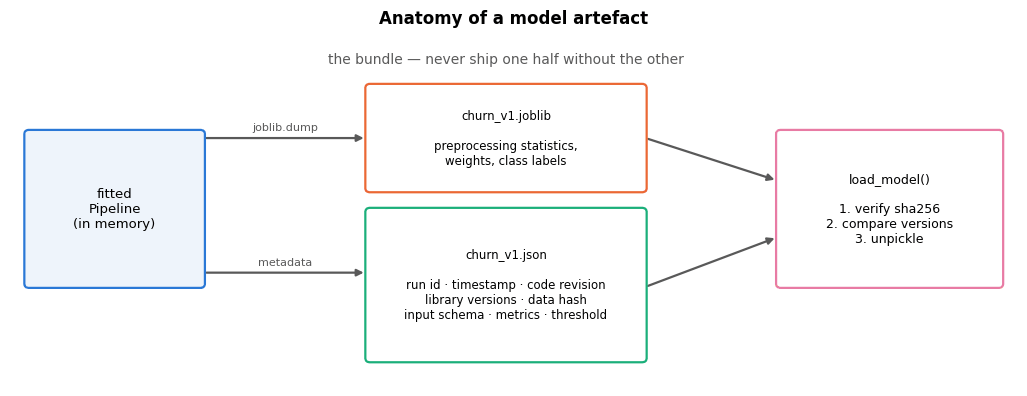

In [16]:
fig, ax = plt.subplots(figsize=(13, 4.6))
blank_axes(ax, (0, 13), (0, 5))
box(ax, 0.2, 1.4, 2.3, 2.2, "fitted\nPipeline\n(in memory)", ec=PALETTE[0], fc="#eef4fb", fontsize=9.5)
# the two files of the bundle: the pickled model and its JSON metadata
box(ax, 4.6, 2.75, 3.6, 1.5, "churn_v1.joblib\n\npreprocessing statistics,\nweights, class labels",
    ec=PALETTE[1], fontsize=8.5)
box(ax, 4.6, 0.35, 3.6, 2.15,
    "churn_v1.json\n\nrun id · timestamp · code revision\nlibrary versions · data hash\ninput schema · metrics · threshold",
    ec=PALETTE[2], fontsize=8.5)
box(ax, 9.9, 1.4, 2.9, 2.2, "load_model()\n\n1. verify sha256\n2. compare versions\n3. unpickle",
    ec=PALETTE[4], fontsize=9)
arrow(ax, (2.5, 3.5), (4.6, 3.5), label="joblib.dump", dy=0.08)
arrow(ax, (2.5, 1.6), (4.6, 1.6), label="metadata", dy=0.08)
arrow(ax, (8.2, 3.5), (9.9, 2.9))
arrow(ax, (8.2, 1.4), (9.9, 2.1))
ax.text(6.4, 4.55, "the bundle — never ship one half without the other",
        ha="center", fontsize=10, color="0.35")
ax.set_title("Anatomy of a model artefact", fontsize=12)
plt.show()

## 5. Testing machine-learning code

Tests for ML systems come in layers. The bottom layer is ordinary software testing (does this
function return what it should?); the top layer is unfamiliar and more interesting, because a
model has no specification to test against — only *properties* we expect it to have.

| Layer | Question | Example here |
|---|---|---|
| **Unit** | does the feature function do what it says? | `new_customer` is 1 exactly when tenure < 6 |
| **Schema / data** | is this batch shaped like the training data? | `monthly_charges` ∈ [0, 200], `contract` in 3 known levels |
| **Invariance** | do irrelevant changes leave the prediction alone? | row order, a tiny rounding of a charge |
| **Directional** | does a change move the prediction the right way? | one more support ticket ⇒ churn risk not lower |
| **Minimum functionality** | are the obvious cases obviously right? | a 2-month month-to-month customer with 5 tickets scores high |
| **Integration** | does the whole path work? | fit → save → load → score a CSV |
| **Quality gate** | is the model good enough to release? | held-out ROC-AUC ≥ 0.78 |

The middle three come from *behavioural testing*, introduced for NLP by Ribeiro et al. (2020)
as CheckList; the taxonomy transfers directly to tabular models.

### 5.1 Lightweight schema validation

Polyzotis et al. (2018) and Breck et al. (2019) argue that in production the *data* breaks far
more often than the model. A schema is a cheap contract: column, type, range, allowed values,
tolerated missing fraction. Below, one short function that catches the failures that actually
occur.

In [17]:
# one rule set per column: expected type, allowed range or values, the tolerated fraction of missing values,
# and whether the values must be unique
SCHEMA = {
    "customer_id": {"dtype": "string", "required": True, "max_missing": 0.0, "unique": True},
    "tenure_months": {"dtype": "integer", "min": 0, "max": 120, "max_missing": 0.0},
    "monthly_charges": {"dtype": "number", "min": 0, "max": 200, "max_missing": 0.05},
    "total_charges": {"dtype": "number", "min": 0, "max": 20000, "max_missing": 0.10},
    "support_tickets": {"dtype": "integer", "min": 0, "max": 20, "max_missing": 0.0},
    "senior_citizen": {"dtype": "integer", "allowed": [0, 1], "max_missing": 0.0},
    "contract": {"dtype": "string", "allowed": ["Month-to-month", "One year", "Two year"]},
    "internet_service": {"dtype": "string", "allowed": ["DSL", "Fiber optic", "No"]},
    "region": {"dtype": "string", "allowed": ["North", "South", "East", "West"]},
}


def validate(df: pd.DataFrame, schema: dict = SCHEMA) -> list[str]:
    """Return a list of human-readable schema violations (empty list == valid batch).

    For every column in `schema` it checks whichever rules the column has: presence, fraction missing,
    numeric type and integer values, the min / max range, the allowed values and uniqueness.
    """
    problems = []
    for column, rule in schema.items():
        if column not in df.columns:
            problems.append(f"{column}: column is missing")
            continue                                     # nothing else can be checked for an absent column
        s = df[column]
        missing = float(s.isna().mean())                 # fraction missing (the mean of a True/False column)
        if missing > rule.get("max_missing", 1.0):       # dict.get(key, default): no rule -> 1.0, anything goes
            # :.1% formats a fraction as a percentage with one decimal
            problems.append(f"{column}: {missing:.1%} missing, at most {rule['max_missing']:.1%} tolerated")
        if rule["dtype"] in {"number", "integer"}:
            values = pd.to_numeric(s, errors="coerce")           # a JSON client may send "42"
            # errors="coerce" turned unparsable values into NaN: count values that are NaN now but were not before
            unparsable = int((values.isna() & s.notna()).sum())
            if unparsable:
                problems.append(f"{column}: {unparsable} values are not numeric (dtype {s.dtype})")
                continue
            # x % 1 is the fractional part of x: for an integer column it must be (close to) 0 everywhere
            if rule["dtype"] == "integer" and not np.allclose(values.dropna() % 1, 0):
                problems.append(f"{column}: expected integers")
            # a missing min / max rule becomes -inf / +inf, so no value can break it
            below = int((values < rule.get("min", -np.inf)).sum())
            above = int((values > rule.get("max", np.inf)).sum())
            if below or above:
                problems.append(f"{column}: {below} values below {rule.get('min')}, "
                                f"{above} above {rule.get('max')}")
        if "allowed" in rule:
            # set difference: the distinct values in the data that are not in the allowed list
            unknown = sorted(set(s.dropna().unique()) - set(rule["allowed"]))
            if unknown:
                problems.append(f"{column}: unexpected values {unknown[:4]}")     # show at most four
        if rule.get("unique") and s.duplicated().any():  # .duplicated() is True for every repeat of an earlier value
            problems.append(f"{column}: {int(s.duplicated().sum())} duplicate values")
    return problems


# an empty list counts as False, so `validate(...) or "no violations"` prints the text when nothing was found
print("clean training batch ->", validate(X_train) or "no violations")
broken = X_train.head(200).copy()                                # 200 rows we are free to corrupt
broken.loc[broken.index[:3], "monthly_charges"] = 950.0          # billing bug
broken.loc[broken.index[3:60], "total_charges"] = np.nan         # upstream join failure
broken.loc[broken.index[60], "contract"] = "Two-year"            # renamed category
broken = broken.drop(columns=["support_tickets"])                # column dropped upstream
print("\ncorrupted batch:")
for problem in validate(broken):
    print("  -", problem)

clean training batch -> no violations

corrupted batch:
  - monthly_charges: 0 values below 0, 3 above 200
  - total_charges: 32.5% missing, at most 10.0% tolerated
  - support_tickets: column is missing
  - contract: unexpected values ['Two-year']


Each of those four corruptions is a real incident type: a unit error, a broken join, a
renamed category, a schema change. `pandera` and Great Expectations give you the same checks
declaratively, with report rendering and integration into data pipelines; the value is in
*having* a schema, not in which library holds it.

### 5.2 A test suite, written to a file and executed

Tests belong in files, not in cells, so that a CI server can run them. We write a small suite
next to the module and execute it with `pytest` when it is available, falling back to a runner
that does the same job with the standard library.

In [18]:
# TESTS_SOURCE is the text of a pytest test file, written to artifacts/test_churn_model.py below. pytest runs every
# function whose name starts with test_: a test passes if it runs to the end, and fails when an `assert condition,
# message` meets a False condition. What the file contains:
#   _load(path), candidate()   load the model that candidate.json points to; @lru_cache stores the result,
#                              so each model file is unpickled only once
#   sample(n)                  n cleaned customers, drawn with a fixed seed (also cached)
#   unit tests                 the new_customer / total_charges_missing flags; add_features keeps the row count,
#                              does not modify its input and does not depend on row order; clean() removes
#                              duplicates and impossible values
#   invariance tests           reversing the row order, or rounding monthly charges and adding 0.004, leaves
#                              P(churn) (almost) unchanged
#   directional tests          one more support ticket never lowers the risk; 12 more months of tenure never raise it
#   minimum functionality      an obvious churner scores > 0.7 and an obviously loyal customer < 0.2
#   reproducibility            two fits on the same 600 rows give the same coefficients
#   quality gate               ROC-AUC >= 0.78 on 1000 customers sampled from the whole cleaned file (so, despite the
#                              test's name, about 80 % of them were also in the training set)
TESTS_SOURCE = '''"""test_churn_model.py — unit, schema, behavioural and quality tests."""
from functools import lru_cache
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

import churn_pipeline as cp

HERE = Path(__file__).resolve().parent
CANDIDATE = HERE / "candidate.json"          # the release under test, written by the training job


@lru_cache(maxsize=4)
def _load(path: str):
    return joblib.load(path)


def candidate():
    """The model the release process nominated (a pointer file keeps the tests model-agnostic)."""
    return _load(str(HERE / json.loads(CANDIDATE.read_text())["model_file"]))


@lru_cache(maxsize=1)
def sample(n: int = 400) -> pd.DataFrame:
    return cp.clean(cp.load_raw()).sample(n, random_state=0).reset_index(drop=True)


def test_new_customer_flag_matches_definition():
    df = pd.DataFrame({"customer_id": ["a", "b", "c"], "signup_date": ["2024-01-01"] * 3,
                       "tenure_months": [0, 5, 6], "support_tickets": [0, 1, 2],
                       "monthly_charges": [10.0, 20.0, 30.0], "total_charges": [1.0, np.nan, 3.0]})
    out = cp.add_features(df)
    assert list(out["new_customer"]) == [1, 1, 0]
    assert list(out["total_charges_missing"]) == [0, 1, 0]


def test_add_features_is_row_wise_and_pure():
    df = sample(50)
    before = df.copy()
    out = cp.add_features(df)
    assert len(out) == len(df), "add_features must not change the number of rows"
    pd.testing.assert_frame_equal(df, before)            # no mutation of the caller's frame
    shuffled = cp.add_features(df.iloc[::-1]).sort_index()
    pd.testing.assert_series_equal(out["tickets_x_charges"], shuffled["tickets_x_charges"])


def test_cleaning_removes_duplicates_and_impossible_values():
    raw = cp.load_raw()
    cleaned = cp.clean(raw)
    assert not cleaned["customer_id"].duplicated().any()
    assert cleaned["monthly_charges"].max() <= 200
    assert set(cleaned["region"].unique()) <= {"North", "South", "East", "West"}


def test_prediction_is_invariant_to_row_order():
    df = sample(200)
    p = cp.predict_proba(candidate(), df)
    p_shuffled = cp.predict_proba(candidate(), df.iloc[::-1])[::-1]
    assert np.allclose(p, p_shuffled, atol=1e-12)


def test_prediction_is_stable_under_a_rounding_change():
    df = sample(200)
    p = cp.predict_proba(candidate(), df)
    jittered = df.assign(monthly_charges=df["monthly_charges"].round(2) + 0.004)
    assert np.max(np.abs(cp.predict_proba(candidate(), jittered) - p)) < 0.01


def test_directional_more_support_tickets_never_lowers_risk():
    df = sample(300)
    p = cp.predict_proba(candidate(), df)
    p_more = cp.predict_proba(candidate(), df.assign(support_tickets=df["support_tickets"] + 1))
    violations = float((p_more < p - 1e-9).mean())
    assert violations == 0.0, f"{violations:.1%} of customers get a LOWER risk after one more ticket"


def test_directional_longer_tenure_never_raises_risk():
    df = sample(300)
    p = cp.predict_proba(candidate(), df)
    p_longer = cp.predict_proba(candidate(), df.assign(tenure_months=df["tenure_months"] + 12))
    assert float((p_longer > p + 1e-9).mean()) == 0.0


def test_minimum_functionality_obvious_cases():
    obvious = pd.DataFrame([
        {"customer_id": "risky", "signup_date": "2024-04-01", "region": "North", "senior_citizen": 0,
         "has_partner": 0, "tenure_months": 2, "contract": "Month-to-month",
         "payment_method": "Electronic check", "internet_service": "Fiber optic", "tech_support": 0,
         "streaming": 1, "monthly_charges": 110.0, "total_charges": 220.0, "support_tickets": 5},
        {"customer_id": "loyal", "signup_date": "2019-01-01", "region": "South", "senior_citizen": 0,
         "has_partner": 1, "tenure_months": 64, "contract": "Two year", "payment_method": "Bank transfer",
         "internet_service": "DSL", "tech_support": 1, "streaming": 0, "monthly_charges": 45.0,
         "total_charges": 2880.0, "support_tickets": 0}])
    p = cp.predict_proba(candidate(), obvious)
    assert p[0] > 0.7, f"the obvious churner scored only {p[0]:.2f}"
    assert p[1] < 0.2, f"the obviously loyal customer scored {p[1]:.2f}"


def test_training_is_reproducible():
    df = sample(600)
    X, y = df[cp.RAW_COLUMNS], df[cp.TARGET]
    a = cp.train(X, y).named_steps["model"].coef_
    b = cp.train(X, y).named_steps["model"].coef_
    assert np.allclose(a, b)


def test_quality_gate_on_held_out_data():
    df = cp.clean(cp.load_raw()).sample(1000, random_state=7)
    auc = roc_auc_score(df[cp.TARGET], cp.predict_proba(candidate(), df))
    assert auc >= 0.78, f"held-out ROC-AUC {auc:.3f} is below the release gate of 0.78"
'''
tests_path = ARTIFACTS / "test_churn_model.py"
tests_path.write_text(TESTS_SOURCE)
# candidate.json names the model under test: the tests read it, so the same suite can test any model version
(ARTIFACTS / "candidate.json").write_text(json.dumps({"model_file": "models/churn_v1.joblib"}))
# sum() over True / False values counts the lines that start a test function (True counts as 1)
print(f"wrote {tests_path.name} with "
      f"{sum(line.startswith('def test_') for line in TESTS_SOURCE.splitlines())} tests, "
      f"and candidate.json pointing at churn_v1")

wrote test_churn_model.py with 10 tests, and candidate.json pointing at churn_v1


The runner below is the piece that makes this notebook self-contained. `pytest` is the tool
you should use; when it is absent we import the module and call every `test_*` function
ourselves, printing the same information a `pytest -q` run would.

In [19]:
import importlib.util        # find_spec / spec_from_file_location: find and load modules by name or by file path
import tempfile              # TemporaryDirectory(): a scratch folder, deleted again when its with block ends
import xml.etree.ElementTree as ET     # the standard library's XML parser, used to read pytest's results file


def run_tests(path: Path = tests_path) -> pd.DataFrame:
    """Run the suite with pytest when installed, otherwise with a standard-library fallback.

    Prints a pytest-like report. Either runner returns one row per test with the columns test, status
    (PASSED / FAILED / ERROR, and SKIPPED under pytest), seconds and detail.
    """
    if importlib.util.find_spec("pytest") is not None:         # find_spec gives None if a package is not installed
        with tempfile.TemporaryDirectory() as tmp:
            report = Path(tmp) / "report.xml"
            # sys.executable is this notebook's Python interpreter; "-m pytest" runs pytest as a module, -q = short
            # report; -p no:cacheprovider: leave no .pytest_cache folder behind; --junit-xml: also write the results
            # to an XML file in the JUnit format that CI servers read
            proc = subprocess.run([sys.executable, "-m", "pytest", str(path), "-q", "--no-header",
                                   "-p", "no:cacheprovider", f"--junit-xml={report}"],
                                  capture_output=True, text=True)
            print(proc.stdout[-2500:])             # the last 2500 characters (the summary is at the end)
            # the XML has one <testcase> element per test; one that did not pass also has a child element: <failure>
            # (pytest's name for any exception inside the test), <error> (one outside it, e.g. in a fixture) or
            # <skipped>, whose message attribute holds the exception text or the skip reason
            status_of = {"failure": "FAILED", "error": "ERROR", "skipped": "SKIPPED"}
            results = []
            for case in ET.parse(report).getroot().iter("testcase"):    # .iter() finds the elements at any depth
                # next() returns the first such child, or the default None when there is none
                outcome = next((child for child in case if child.tag in status_of), None)
                if outcome is None:
                    status, detail = "PASSED", ""
                else:
                    status = status_of[outcome.tag]
                    # as in the fallback: the first line of the message, cut to 110 characters, without the
                    # "AssertionError: " that pytest puts in front of an assert message
                    detail = outcome.get("message", "").removeprefix("AssertionError: ").split("\n")[0][:110]
                results.append({"test": case.get("name"), "status": status, "seconds": float(case.get("time")),
                                "detail": detail})
        return pd.DataFrame(results)
    # fallback: import the test file as a module from its path, in the three steps importlib uses internally
    module_name = path.stem                        # the file name without .py
    spec = importlib.util.spec_from_file_location(module_name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module              # register it under its name, as a normal import would
    spec.loader.exec_module(module)                # run the file's code, which defines the test functions
    results = []
    print(f"===== test session (fallback runner: pytest is not installed) — {path.name} =====")
    # dir(module) lists the module's names in alphabetical order, so the tests run alphabetically
    for test_name in [n for n in dir(module) if n.startswith("test_")]:
        t0 = time.perf_counter()
        try:
            getattr(module, test_name)()           # getattr fetches the function by its name, () calls it
            status, detail = "PASSED", ""
        except AssertionError as exc:              # an assert found a False condition: the test FAILED
            # the first line of the assert message, cut to 110 characters
            status, detail = "FAILED", str(exc).splitlines()[0][:110]
        except Exception as exc:                    # an error is not the same as a failure
            status, detail = "ERROR", f"{type(exc).__name__}: {exc}"
        dt = time.perf_counter() - t0
        results.append({"test": test_name, "status": status, "seconds": dt, "detail": detail})
        print(f"  {test_name:<52s} {status:<7s} {dt:5.2f}s")      # :<52s left-aligns the name in 52 characters
        if detail:
            print(f"      -> {detail}")
    df = pd.DataFrame(results)
    counts = df["status"].value_counts()           # the number of tests with each status
    print("-" * 78)
    # a pytest-style summary line: "<count> passed, <count> failed ... in <total time>s"
    print(", ".join(f"{n} {s.lower()}" for s, n in counts.items()) +
          f" in {df['seconds'].sum():.2f}s")
    return df


results_v1 = run_tests()       # candidate.json currently points at churn_v1

===== test session (fallback runner: pytest is not installed) — test_churn_model.py =====
  test_add_features_is_row_wise_and_pure               PASSED   0.02s
  test_cleaning_removes_duplicates_and_impossible_values PASSED   0.01s
  test_directional_longer_tenure_never_raises_risk     PASSED   0.03s
  test_directional_more_support_tickets_never_lowers_risk FAILED   0.02s
      -> 10.3% of customers get a LOWER risk after one more ticket
  test_minimum_functionality_obvious_cases             PASSED   0.01s
  test_new_customer_flag_matches_definition            PASSED   0.00s
  test_prediction_is_invariant_to_row_order            PASSED   0.04s
  test_prediction_is_stable_under_a_rounding_change    PASSED   0.02s
  test_quality_gate_on_held_out_data                   PASSED   0.03s
  test_training_is_reproducible                        PASSED   0.05s
------------------------------------------------------------------------------
9 passed, 1 failed in 0.23s


### 5.3 A failing test is the suite doing its job

One directional test fails, and the failure is real. The model uses both `support_tickets` and
the interaction `tickets_x_charges = support_tickets × monthly_charges`. Their fitted
coefficients have opposite signs, so one extra ticket changes the log-odds by

$$
\Delta \;=\; \frac{w_{\text{tickets}}}{s_{\text{tickets}}}
\;+\; \frac{w_{\text{interaction}}}{s_{\text{interaction}}}\cdot \text{monthly\_charges},
$$

where $s$ are the standard deviations the scaler learned. With $w_{\text{tickets}} < 0$ this is
positive only above a break-even price — computed below, and around 22 currency units, which
about one customer in eight falls under. Nobody intended that; it is an artefact of fitting two
collinear features, and only a behavioural test could find it, because the effect is far too
small (a few thousandths of a probability) to show up in any accuracy metric.

fitted weights of the two ticket features (standardised units):
support_tickets     -0.245
tickets_x_charges    1.028
one extra ticket raises the log-odds only when monthly charges exceed 22.0


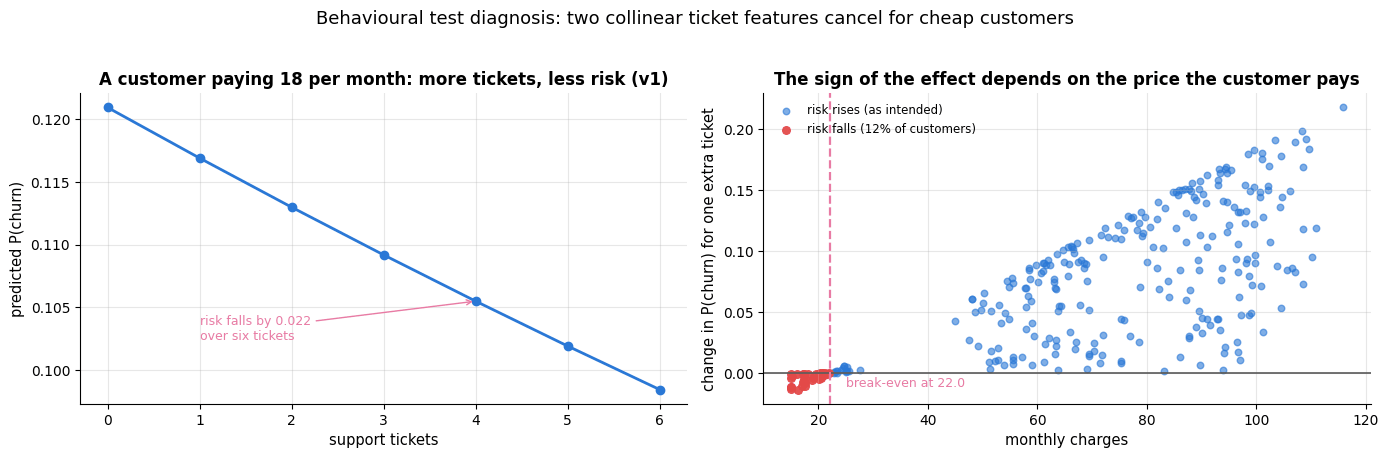

In [20]:
prep_v1 = model_v1.named_steps["prep"]            # v1's fitted ColumnTransformer
# coef_ has shape (1, n_features) for a binary problem, [0] takes its single row; get_feature_names_out() names the
# columns the ColumnTransformer outputs, in order, so every weight is labelled with its feature
weights = pd.Series(model_v1.named_steps["model"].coef_[0], index=prep_v1.get_feature_names_out())
# named_transformers_ gives the fitted branches by name; scale_ holds the standard deviation that StandardScaler
# learned for each numeric column (in the order of cp.NUMERIC)
scales = pd.Series(prep_v1.named_transformers_["num"].named_steps["scale"].scale_, index=cp.NUMERIC)
# set the change in log-odds from the markdown above to 0 and solve for monthly_charges:
# w_t / s_t + (w_i / s_i) * charges = 0   ->   charges = -(w_t / s_t) / (w_i / s_i)
break_even = -(weights["support_tickets"] / scales["support_tickets"]) / (
    weights["tickets_x_charges"] / scales["tickets_x_charges"])
print("fitted weights of the two ticket features (standardised units):")
print(weights[["support_tickets", "tickets_x_charges"]].round(3).to_string())   # to_string(): plain text, no dtype line
print(f"one extra ticket raises the log-odds only when monthly charges exceed {break_even:.1f}")

# one fixed customer; only monthly_charges and support_tickets are set (and varied) below
profile = {"customer_id": "probe", "signup_date": "2022-06-01", "region": "North", "senior_citizen": 0,
           "has_partner": 0, "tenure_months": 24, "contract": "Month-to-month",
           "payment_method": "Electronic check", "internet_service": "DSL", "tech_support": 0,
           "streaming": 0, "total_charges": 1200.0}
tickets = np.arange(0, 7)                         # 0, 1, ..., 6 support tickets
# {**profile, ...} copies the profile and adds two keys: one row per ticket count, all paying 18 per month
cheap = pd.DataFrame([{**profile, "monthly_charges": 18.0, "support_tickets": t} for t in tickets])
p_cheap = cp.predict_proba(model_v1, cheap)       # P(churn) as the ticket count rises
probe_sample = X_test.sample(300, random_state=1)          # 300 random test customers
# the change in P(churn) when each of them gets one extra ticket, shape (300,)
delta = (cp.predict_proba(model_v1, probe_sample.assign(support_tickets=probe_sample["support_tickets"] + 1))
         - cp.predict_proba(model_v1, probe_sample))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
axes[0].plot(tickets, p_cheap, marker="o", color=PALETTE[0])
axes[0].annotate(f"risk falls by {p_cheap[0] - p_cheap[-1]:.3f}\nover six tickets",
                 xy=(4, p_cheap[4]), xytext=(1.0, p_cheap.min() + 0.004), fontsize=9, color=PALETTE[4],
                 arrowprops=dict(arrowstyle="->", color=PALETTE[4]))
axes[0].set_xlabel("support tickets")
axes[0].set_ylabel("predicted P(churn)")
axes[0].set_title("A customer paying 18 per month: more tickets, less risk (v1)")
negative = delta < 0                              # True for customers whose risk FALLS with one more ticket
# ~negative inverts the mask: the customers whose risk rises (or stays the same)
axes[1].scatter(probe_sample.loc[~negative, "monthly_charges"], delta[~negative], s=22, alpha=0.6,
                color=PALETTE[0], label="risk rises (as intended)")
axes[1].scatter(probe_sample.loc[negative, "monthly_charges"], delta[negative], s=30, alpha=0.9,
                color=PALETTE[7], label=f"risk falls ({negative.mean():.0%} of customers)")
axes[1].axhline(0, color="0.35", lw=1.2)                       # no change
axes[1].axvline(break_even, color=PALETTE[4], ls="--", lw=1.6)  # the break-even price computed above
axes[1].annotate(f"break-even at {break_even:.1f}", xy=(break_even + 3, delta.min() * 0.8), fontsize=9,
                 color=PALETTE[4])
axes[1].set_xlabel("monthly charges")
axes[1].set_ylabel("change in P(churn) for one extra ticket")
axes[1].set_title("The sign of the effect depends on the price the customer pays")
axes[1].legend(fontsize=8.5, loc="upper left")
fig.suptitle("Behavioural test diagnosis: two collinear ticket features cancel for cheap customers",
             y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

The remedy is a modelling decision, not a patch: keep the interaction, drop the raw count, and
re-check both accuracy and behaviour. The experiment log already contains that candidate
("logreg C=1, no raw tickets") with a cross-validated score indistinguishable from the
baseline, so the cost of the fix is known before we make it.

In [21]:
# keep the interaction, drop the raw ticket count. A column listed in no branch of the ColumnTransformer is
# dropped (its default is remainder="drop"), so support_tickets now reaches the model only via tickets_x_charges
numeric_v2 = [c for c in cp.NUMERIC if c != "support_tickets"]
model_v2 = cp.train(X_train, y_train, numeric=numeric_v2)
p_test_v2 = cp.predict_proba(model_v2, X_test)
print(f"v1 held-out ROC-AUC {roc_auc_score(y_test, p_test):.4f}  (5 numeric features)")
print(f"v2 held-out ROC-AUC {roc_auc_score(y_test, p_test_v2):.4f}  (raw ticket count removed)")

# register v2 exactly like v1, with a note that says why it exists
meta_v2 = save_model(model_v2, "churn", "v2", features=cp.RAW_COLUMNS, data_hash=data_hash,
                     threshold=config["serving"]["decision_threshold"],
                     notes="v1 minus the raw support_tickets column: restores monotonicity in tickets.",
                     metrics={"roc_auc": roc_auc_score(y_test, p_test_v2),
                              "average_precision": average_precision_score(y_test, p_test_v2),
                              "brier": brier_score_loss(y_test, p_test_v2),
                              "n_train": len(X_train), "n_test": len(X_test)})
# point candidate.json at v2, so that the unchanged test suite now tests the new model
(ARTIFACTS / "candidate.json").write_text(json.dumps({"model_file": "models/churn_v2.joblib"}))
results_v2 = run_tests()

v1 held-out ROC-AUC 0.8330  (5 numeric features)
v2 held-out ROC-AUC 0.8323  (raw ticket count removed)
===== test session (fallback runner: pytest is not installed) — test_churn_model.py =====
  test_add_features_is_row_wise_and_pure               PASSED   0.02s
  test_cleaning_removes_duplicates_and_impossible_values PASSED   0.01s
  test_directional_longer_tenure_never_raises_risk     PASSED   0.03s
  test_directional_more_support_tickets_never_lowers_risk PASSED   0.03s
  test_minimum_functionality_obvious_cases             PASSED   0.01s
  test_new_customer_flag_matches_definition            PASSED   0.00s
  test_prediction_is_invariant_to_row_order            PASSED   0.04s
  test_prediction_is_stable_under_a_rounding_change    PASSED   0.02s
  test_quality_gate_on_held_out_data                   PASSED   0.02s
  test_training_is_reproducible                        PASSED   0.05s
------------------------------------------------------------------------------
10 passed in 0.24s


,sklearn,ROC-AUC,Brier,bytes,notes
version,,,,,
v1,1.8.0,0.8330,0.1512,7402,Baseline: notebook 4 featu…
v2,1.8.0,0.8323,0.1515,7306,v1 minus the raw support_t…


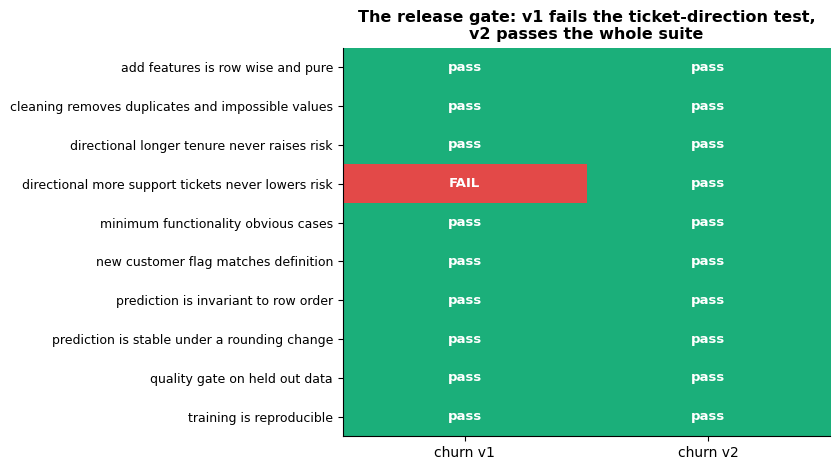

In [22]:
# read every registered model's JSON sidecar, one row each. The glob pattern [0-9] matches exactly one digit,
# so churn_v1.json and churn_v2.json match but churn_v1_stale.json does not
registry = pd.DataFrame([json.loads(p.read_text()) for p in sorted(MODEL_DIR.glob("churn_v[0-9].json"))])
# the environment, metrics and artifact columns hold dicts, so the list comprehensions pull single fields out
registry_view = pd.DataFrame({
    "version": registry["version"], "sklearn": [e["scikit-learn"] for e in registry["environment"]],
    "ROC-AUC": [m["roc_auc"] for m in registry["metrics"]],
    "Brier": [m["brier"] for m in registry["metrics"]],
    "bytes": [a["bytes"] for a in registry["artifact"]],
    "notes": [n[:26] + "…" for n in registry["notes"]]}).set_index("version")    # first 26 characters of each note
display(registry_view)        # display() renders a table even when it is not the last line of the cell

# a (tests x 2) table with 1 = passed, 0 = failed or error: .eq("PASSED") gives True / False, .astype(int) 1 / 0,
# .to_frame("v1") makes a one-column DataFrame and .join adds the v2 column, matched by test name.
# (either runner returns these tables; rows follow results_v1: file order under pytest, alphabetical otherwise)
grid = (results_v1.set_index("test")["status"].eq("PASSED").astype(int)
        .to_frame("v1").join(results_v2.set_index("test")["status"].eq("PASSED").astype(int).rename("v2")))
fig, ax = plt.subplots(figsize=(8.5, 4.8))
# ListedColormap([red, green]) with vmin=0, vmax=1: 0 (fail) is drawn red and 1 (pass) green
ax.imshow(grid.to_numpy(), cmap=plt.matplotlib.colors.ListedColormap([PALETTE[7], PALETTE[2]]),
          aspect="auto", vmin=0, vmax=1)
# "test_cleaning_removes_..." -> "cleaning removes ..." for the row labels
ax.set_yticks(range(len(grid)), [t.replace("test_", "").replace("_", " ") for t in grid.index],
              fontsize=9)
ax.set_xticks([0, 1], ["churn v1", "churn v2"], fontsize=10)
for i in range(grid.shape[0]):
    for j in range(2):
        ax.text(j, i, "pass" if grid.iloc[i, j] else "FAIL", ha="center", va="center",
                color="white", fontsize=9.5, weight="bold")
ax.grid(False)
ax.set_title("The release gate: v1 fails the ticket-direction test,\nv2 passes the whole suite",
             fontsize=11.5)
plt.tight_layout()
plt.show()

> **Key idea.** The suite did not tell us that v2 is a better model — its cross-validated
> accuracy is the same. It told us that v1 had a *behaviour* we could not defend to a retention
> manager ("why does calling support make the model think I am happier?"). Tests encode
> requirements that metrics cannot see.

```py
# On your machine, with pytest installed, this is the whole story:
#   $ pytest tests/ -q                       # run everything
#   $ pytest tests/ -q -k directional        # one behavioural family
#   $ pytest tests/ --durations=5            # find the slow tests
# In CI (GitHub Actions, GitLab CI), the same command gates the merge; a nightly job re-runs
# the quality gate against fresh data so that a *data* regression also fails the build.
```

## 6. Serving: batch and online

### 6.1 Two shapes of inference

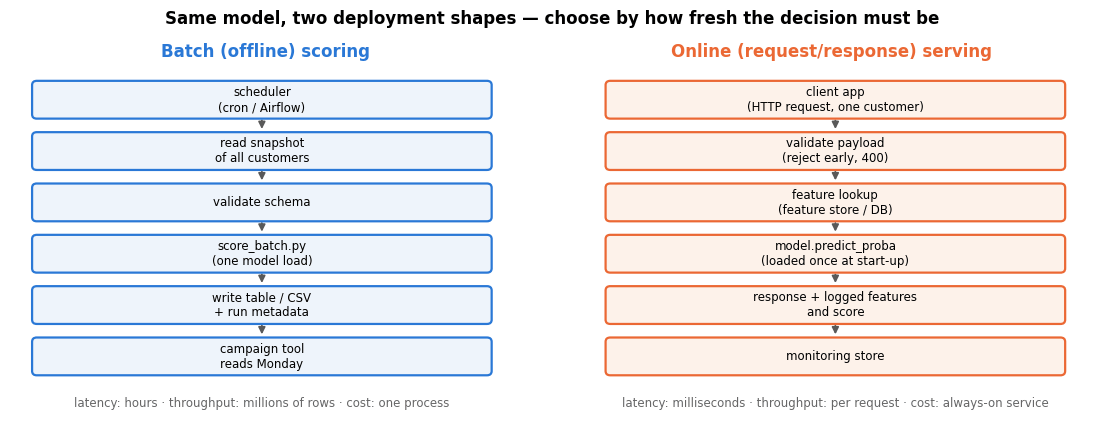

In [23]:
fig, ax = plt.subplots(figsize=(14, 5))
blank_axes(ax, (0, 14), (0, 5.4))
ax.text(3.3, 5.05, "Batch (offline) scoring", ha="center", fontsize=12, weight="semibold", color=PALETTE[0])
ax.text(10.6, 5.05, "Online (request/response) serving", ha="center", fontsize=12, weight="semibold",
        color=PALETTE[1])
batch = ["scheduler\n(cron / Airflow)", "read snapshot\nof all customers", "validate schema",
         "score_batch.py\n(one model load)", "write table / CSV\n+ run metadata", "campaign tool\nreads Monday"]
for i, text in enumerate(batch):
    box(ax, 0.3, 4.2 - i * 0.72, 5.9, 0.50, text, ec=PALETTE[0], fc="#eef4fb", fontsize=8.5)   # each box 0.72 lower
    if i:                        # every box except the first (i = 0 counts as False) gets an arrow from the one above
        arrow(ax, (3.25, 4.92 - i * 0.72), (3.25, 4.72 - i * 0.72), lw=1.3)
online = ["client app\n(HTTP request, one customer)", "validate payload\n(reject early, 400)",
          "feature lookup\n(feature store / DB)", "model.predict_proba\n(loaded once at start-up)",
          "response + logged features\nand score", "monitoring store"]
for i, text in enumerate(online):
    box(ax, 7.7, 4.2 - i * 0.72, 5.9, 0.50, text, ec=PALETTE[1], fc="#fdf2ea", fontsize=8.5)
    if i:
        arrow(ax, (10.65, 4.92 - i * 0.72), (10.65, 4.72 - i * 0.72), lw=1.3)
ax.text(3.25, 0.15, "latency: hours · throughput: millions of rows · cost: one process",
        ha="center", fontsize=8.5, color="0.4")
ax.text(10.65, 0.15, "latency: milliseconds · throughput: per request · cost: always-on service",
        ha="center", fontsize=8.5, color="0.4")
ax.set_title("Same model, two deployment shapes — choose by how fresh the decision must be", fontsize=12)
plt.show()

Batch is the right default: it is simpler, cheaper, easier to test and easier to reason about,
and most business decisions (a retention campaign, a weekly credit review, a restock order)
tolerate a day of staleness. Choose online serving when the decision depends on information
that only exists at request time (what the user just clicked) or must be acted on immediately.

### 6.2 A batch scoring script

In [24]:
# SCORER_SOURCE is the text of a stand-alone command-line script, written to artifacts/score_batch.py below:
#   sys.path.insert(...)   lets the script import churn_pipeline from its own folder
#   argparse               declares the options --model, --input, --output (required) and --threshold (optional)
#                          and reads them from the command line into args.model, args.input, ...
#   main()                 reads the JSON sidecar next to the model (for its name and threshold), loads the model,
#                          cleans the input CSV, stops with exit code 2 if a required column is missing, then writes
#                          one row per customer: customer_id, p_churn, contact (1 if p_churn >= threshold), the
#                          model name and a timestamp
#   if __name__ == "__main__":   true only when the file is run as a script, not when it is imported;
#                          raise SystemExit(main()) makes main's return value the exit code (0 = success)
SCORER_SOURCE = '''"""score_batch.py — score a CSV of raw customer rows with a registered model."""
import argparse
import json
import sys
from datetime import datetime, timezone
from pathlib import Path

import joblib
import pandas as pd

sys.path.insert(0, str(Path(__file__).resolve().parent))
import churn_pipeline as cp


def main(argv=None) -> int:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--model", required=True, help="path to the .joblib bundle")
    parser.add_argument("--input", required=True, help="CSV of raw customer rows")
    parser.add_argument("--output", required=True, help="where to write the scored CSV")
    parser.add_argument("--threshold", type=float, default=None, help="overrides the metadata threshold")
    args = parser.parse_args(argv)

    model_path = Path(args.model)
    meta = json.loads(model_path.with_suffix(".json").read_text())
    threshold = args.threshold if args.threshold is not None else meta["decision_threshold"]
    model = joblib.load(model_path)

    frame = cp.clean(pd.read_csv(args.input))
    missing = [c for c in cp.RAW_COLUMNS if c not in frame.columns]
    if missing:
        print(f"ERROR: input is missing required columns: {missing}", file=sys.stderr)
        return 2

    scores = cp.predict_proba(model, frame)
    out = pd.DataFrame({"customer_id": frame["customer_id"], "p_churn": scores.round(6),
                        "contact": (scores >= threshold).astype(int),
                        "model": f"{meta['name']}_{meta['version']}",
                        "scored_at": datetime.now(timezone.utc).isoformat(timespec="seconds")})
    out.to_csv(args.output, index=False)
    print(f"scored {len(out)} rows with {meta['name']}_{meta['version']} "
          f"(threshold {threshold:.2f}); flagged {int(out['contact'].sum())} customers "
          f"({out['contact'].mean():.1%}); wrote {args.output}")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())
'''
scorer_path = ARTIFACTS / "score_batch.py"
scorer_path.write_text(SCORER_SOURCE)

incoming_path = ARTIFACTS / "incoming_customers.csv"
X_test.to_csv(incoming_path, index=False)          # tonight's "export": the test customers (index=False: no row labels)
scored_path = ARTIFACTS / "scored_customers.csv"
# run the script in a separate Python process, as a scheduler would; each command-line word is one list item
proc = subprocess.run([sys.executable, str(scorer_path), "--model", str(MODEL_DIR / "churn_v2.joblib"),
                       "--input", str(incoming_path), "--output", str(scored_path)],
                      capture_output=True, text=True)
print(proc.stdout.strip() or proc.stderr.strip())    # the script's message, or its error output if stdout is empty
pd.read_csv(scored_path).head(4)

scored 1000 rows with churn_v2 (threshold 0.50); flagged 277 customers (27.7%); wrote artifacts/scored_customers.csv


,customer_id,p_churn,contact,model,scored_at
0,C01909,0.003846,0,churn_v2,2026-09-19T07:18:41+00:00
1,C02260,0.614785,1,churn_v2,2026-09-19T07:18:41+00:00
2,C00853,0.060444,0,churn_v2,2026-09-19T07:18:41+00:00
3,C01747,0.677476,1,churn_v2,2026-09-19T07:18:41+00:00


A script like this is the *integration test* of the whole system: it exercises the module, the
bundle, the metadata, the threshold and the output contract in one command, and it is what a
scheduler calls at 3 a.m.

### 6.3 An online endpoint, exercised with Flask's test client

The same bundle behind an HTTP interface. Note what the handler does *not* do: it does not
re-implement a single feature. It validates, it calls the pipeline, it logs.

In [25]:
try:
    from flask import Flask, request, jsonify      # Flask: a small web framework for HTTP services
    HAS_FLASK = True
except ImportError:                                 # raised when the package is not installed
    HAS_FLASK = False
    print("Flask is not installed — showing the endpoint as code only (pip install flask).")

if HAS_FLASK:
    serving_model, serving_meta = load_model("churn", "v2")      # loaded once, when the service starts
    THRESHOLD = serving_meta["decision_threshold"]
    # the fields every request must contain
    REQUIRED = ["tenure_months", "monthly_charges", "total_charges", "support_tickets",
                "contract", "payment_method", "internet_service", "region",
                "senior_citizen", "has_partner", "tech_support", "streaming", "signup_date"]
    # Batch-level rules (missing rate, uniqueness) are meaningless for a single row: one missing
    # value is "100 % missing".  The request schema keeps only the per-value rules.
    # (a nested dict comprehension: for every column except customer_id, a copy of its rules without those two)
    REQUEST_SCHEMA = {c: {k: v for k, v in rule.items() if k not in {"max_missing", "unique"}}
                      for c, rule in SCHEMA.items() if c != "customer_id"}
    request_log = []                       # one record per answered request (used for the latency plot below)

    app = Flask("churn-service")           # the application object; URL routes are attached to it with decorators
    app.config["TESTING"] = True           # errors propagate to the caller instead of becoming HTTP 500 responses

    @app.get("/health")                    # the function below answers GET requests for the path /health
    def health():
        """Liveness check: report that the service is up and which model version it serves."""
        # jsonify turns a dict into an HTTP response with a JSON body
        return jsonify({"status": "ok", "model": f"{serving_meta['name']}_{serving_meta['version']}",
                        "trained_at": serving_meta["created_at"]})

    @app.post("/predict")                  # ... and this one answers POST requests for /predict
    def predict():
        """Score one customer sent as a JSON object in the request body.

        Returns status 400 if the body is not a JSON object or a required field is missing, 422 if a value breaks
        the schema, and otherwise 200 with p_churn, the contact decision, the model name and the latency in ms.
        """
        t0 = time.perf_counter()
        payload = request.get_json(silent=True)     # the parsed JSON body; silent=True: None instead of an error
        if not isinstance(payload, dict):
            return jsonify({"error": "body must be a JSON object"}), 400     # (response, status); 400 = Bad Request
        absent = [c for c in REQUIRED if c not in payload]
        if absent:
            return jsonify({"error": "missing fields", "fields": absent}), 400
        # a one-row DataFrame built from the payload; customer_id is optional ("unknown" when absent)
        row = pd.DataFrame([{**payload, "customer_id": payload.get("customer_id", "unknown")}])
        violations = validate(row, REQUEST_SCHEMA)      # the same validate() as for batches, with per-value rules
        if violations:
            # 422 = Unprocessable Entity: well-formed JSON, but values the service cannot accept
            return jsonify({"error": "schema violation", "details": violations}), 422
        p = float(cp.predict_proba(serving_model, row)[0])     # the single probability, as a plain float for JSON
        latency_ms = (time.perf_counter() - t0) * 1000
        # log what was served (score, latency and two inputs), the raw material for monitoring
        request_log.append({"p_churn": p, "latency_ms": latency_ms,
                            "contract": payload["contract"], "tenure_months": payload["tenure_months"]})
        # no status code given: Flask uses 200 OK
        return jsonify({"customer_id": row.loc[0, "customer_id"], "p_churn": round(p, 4),
                        "contact": bool(p >= THRESHOLD),
                        "model": f"{serving_meta['name']}_{serving_meta['version']}",
                        "latency_ms": round(latency_ms, 2)})

    def as_payload(row: pd.Series) -> dict:
        """Turn one row of X_test into the JSON-ready dict a client application would send.

        The signup date is made a string and every missing value (NaN) becomes None, which JSON writes as null.
        """
        record = row.to_dict()                                  # {column name: value}
        record["signup_date"] = str(record["signup_date"])     # JSON has no date type
        return {k: (None if pd.isna(v) else v) for k, v in record.items()}

    client = app.test_client()      # sends requests straight to the app, without starting a web server
    print("GET  /health  ->", client.get("/health").get_json())       # .get_json() parses the response body
    good = client.post("/predict", json=as_payload(X_test.iloc[0]))   # json= sends the dict as a JSON body
    print("POST /predict ->", good.status_code, good.get_json())      # .status_code is the HTTP status
    bad = client.post("/predict", json={"tenure_months": 5})          # an incomplete request
    print("POST /predict (incomplete) ->", bad.status_code, bad.get_json())
    # dict | dict merges two dicts, the right-hand values winning: a complete row with two broken values
    weird = as_payload(X_test.iloc[1]) | {"contract": "Two-year", "monthly_charges": 940.0}
    strange = client.post("/predict", json=weird)
    print("POST /predict (bad values)  ->", strange.status_code, strange.get_json())

GET  /health  -> {'model': 'churn_v2', 'status': 'ok', 'trained_at': '2026-09-19T07:18:40+00:00'}
POST /predict -> 200 {'contact': False, 'customer_id': 'C01909', 'latency_ms': 13.46, 'model': 'churn_v2', 'p_churn': 0.0038}
POST /predict (incomplete) -> 400 {'error': 'missing fields', 'fields': ['monthly_charges', 'total_charges', 'support_tickets', 'contract', 'payment_method', 'internet_service', 'region', 'senior_citizen', 'has_partner', 'tech_support', 'streaming', 'signup_date']}
POST /predict (bad values)  -> 422 {'details': ['monthly_charges: 0 values below 0, 1 above 200', "contract: unexpected values ['Two-year']"], 'error': 'schema violation'}


```py
# The same service with FastAPI, which validates the payload for you via type annotations:
from typing import Literal

from fastapi import FastAPI
from pydantic import BaseModel, Field

class Customer(BaseModel):
    tenure_months: int = Field(ge=0, le=120)
    monthly_charges: float = Field(ge=0, le=200)
    contract: Literal["Month-to-month", "One year", "Two year"]
    # ... the schema of section 5.1, expressed once, enforced on every request

app = FastAPI()

@app.post("/predict")
def predict(customer: Customer):
    row = pd.DataFrame([customer.model_dump()])
    return {"p_churn": float(cp.predict_proba(MODEL, row)[0])}

# Run it with `uvicorn serve:app --workers 4`, put it in a container
# (FROM python:3.11-slim; COPY requirements.lock; pip install; CMD uvicorn ...),
# and let Kubernetes or a managed service handle replicas, health checks and rollout.
```

### 6.4 Latency

Latency is a *feature* of the service, and it is dominated by things that are not the model.
Let us measure the endpoint, then compare with batch scoring of the same rows.

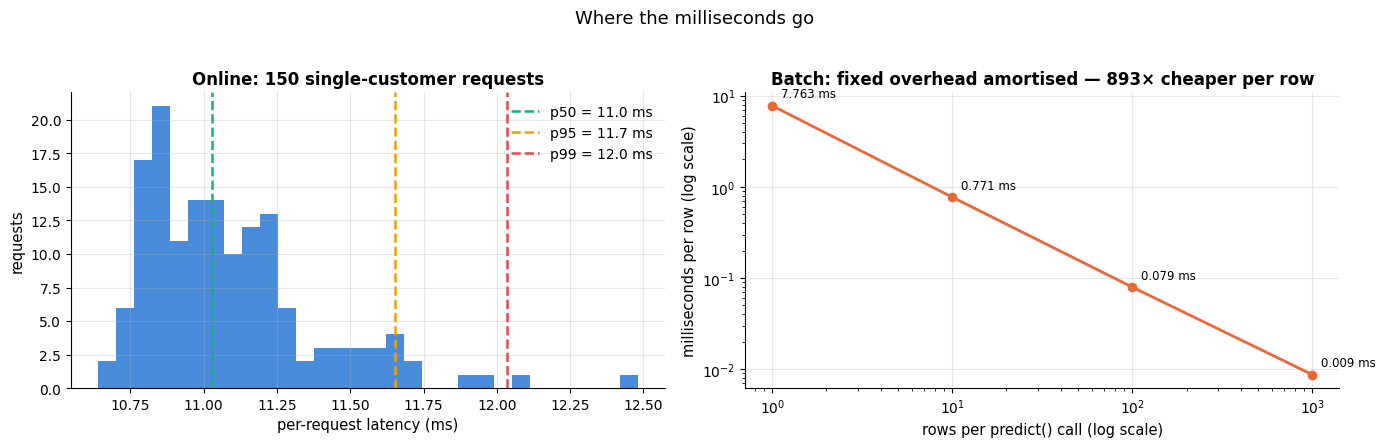

mean 11.08 ms | p95 11.65 ms | budget from the config: 50 ms


In [26]:
if HAS_FLASK:
    payloads = [as_payload(X_test.iloc[i]) for i in range(150)]          # 150 single-customer requests
    for payload in payloads:                                     # warm-up (first call pays import costs)
        client.post("/predict", json=payload)
    request_log.clear()                     # forget the warm-up requests: only the timed run below is kept
    for payload in payloads:
        client.post("/predict", json=payload)
    latencies = np.array([r["latency_ms"] for r in request_log])      # as measured inside predict(), in ms

    # batch scoring: time predict_proba on 1, 10, 100 and 1000 rows per call (5 repeats each)
    sizes = [1, 10, 100, 1000]
    per_row = []
    for n in sizes:
        batch = X_test.iloc[:n]                 # the first n test customers
        t0 = time.perf_counter()
        for _ in range(5):
            cp.predict_proba(serving_model, batch)
        per_row.append((time.perf_counter() - t0) / 5 / n * 1000)    # mean time per call, per row, in ms

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
    axes[0].hist(latencies, bins=30, color=PALETTE[0], alpha=0.85)
    # np.percentile(a, q) is the value below which q % of a lies: half, 95 % and 99 % of the requests were at
    # least as fast as p50, p95 and p99
    for q, colour, label in [(50, PALETTE[2], "p50"), (95, PALETTE[3], "p95"), (99, PALETTE[7], "p99")]:
        v = float(np.percentile(latencies, q))
        axes[0].axvline(v, color=colour, ls="--", lw=1.8, label=f"{label} = {v:.1f} ms")
    axes[0].set_xlabel("per-request latency (ms)")
    axes[0].set_ylabel("requests")
    axes[0].set_title(f"Online: {len(latencies)} single-customer requests")
    axes[0].legend()
    axes[1].plot(sizes, per_row, marker="o", color=PALETTE[1])
    for n, v in zip(sizes, per_row):
        axes[1].annotate(f"{v:.3f} ms", (n, v), textcoords="offset points", xytext=(6, 6), fontsize=8.5)
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("rows per predict() call (log scale)")
    axes[1].set_ylabel("milliseconds per row (log scale)")
    # per_row[0] / per_row[-1]: the cost per row of a 1-row call divided by that of a 1000-row call
    axes[1].set_title(f"Batch: fixed overhead amortised — {per_row[0] / per_row[-1]:.0f}× cheaper per row")
    fig.suptitle("Where the milliseconds go", y=1.03, fontsize=13)
    plt.tight_layout()
    plt.show()
    print(f"mean {latencies.mean():.2f} ms | p95 {np.percentile(latencies, 95):.2f} ms | "
          f"budget from the config: {config['serving']['max_latency_ms']} ms")

Almost none of that time is the dot product. It is building a one-row DataFrame, running a
`ColumnTransformer`, serialising JSON. The lesson generalises: **profile before optimising**,
and prefer batching over micro-optimising. Report the *tail* (p95/p99), not the mean — the
mean is what your users never experience.

### 6.5 Training–serving skew

The most expensive bug in applied ML has no traceback: the features computed at serving time
differ from those computed at training time. Sources, in rough order of frequency:

| Source | Example | Prevention |
|---|---|---|
| Re-implemented features | the service computes `tenure` in days, training used months | one module, imported by both |
| Statistics recomputed at serving | scaling with the *request batch's* mean instead of the stored training mean | put the scaler in the pipeline |
| Different defaults for missing values | training imputes the median, the service sends 0 | the pipeline imputes; the service never does |
| Time travel in training data | a feature that was not yet known at decision time | point-in-time-correct joins; a feature store |
| Stale features | the service reads a nightly table while training used live data | monitor feature freshness; log served features |

Row two is the classic. Below, a "serving implementation" that scales each incoming batch with
its own statistics — an easy mistake, and invisible until the batch mix changes.

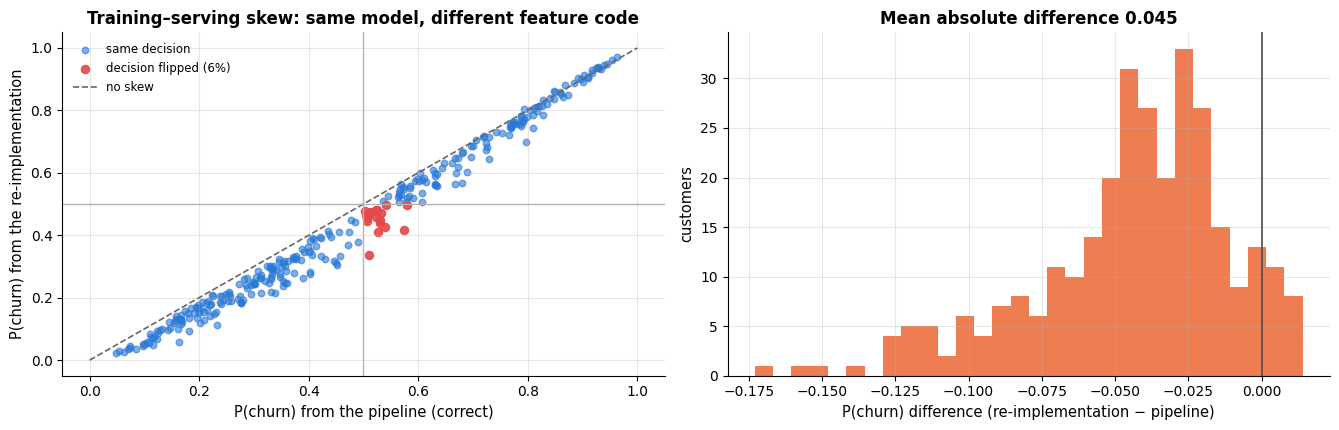

18 of 300 contact decisions change; largest difference 0.173


In [27]:
prep = model_v2.named_steps["prep"]               # v2's fitted ColumnTransformer
# the fitted scaler and imputer of the numeric branch ("num"). The re-implementation below never uses
# scaler.mean_ / scaler.scale_ (the stored training statistics): that is exactly the mistake
scaler = prep.named_transformers_["num"].named_steps["scale"]
imputer = prep.named_transformers_["num"].named_steps["impute"]


def skewed_serving_scores(rows: pd.DataFrame) -> np.ndarray:
    """A plausible-looking re-implementation that standardises with the REQUEST batch statistics.

    Uses v2's own features, imputer and classifier; only the numeric columns are scaled with the mean and standard
    deviation of `rows` instead of the training values. Returns P(churn) per row, shape (len(rows),).
    """
    engineered = cp.add_features(rows)
    # the fitted imputer fills NaN with the training medians; wrapped as a DataFrame with the numeric column names
    numeric = pd.DataFrame(imputer.transform(engineered[numeric_v2]), columns=numeric_v2)
    numeric = (numeric - numeric.mean()) / numeric.std(ddof=0)          # <- the bug
    design = prep.transform(engineered)           # the correct design matrix (a DataFrame, thanks to set_output)
    design[numeric_v2] = numeric.to_numpy()       # overwrite its numeric columns; .to_numpy() avoids index alignment
    return model_v2.named_steps["model"].predict_proba(design)[:, 1]    # column 1 = P(churn)


campaign = X_test[X_test["contract"] == "Month-to-month"].head(300)     # a non-representative batch
p_correct = cp.predict_proba(model_v2, campaign)
p_skewed = skewed_serving_scores(campaign)
flipped = (p_correct >= 0.5) != (p_skewed >= 0.5)       # True where the two versions make different contact decisions

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
axes[0].scatter(p_correct[~flipped], p_skewed[~flipped], s=22, alpha=0.6, color=PALETTE[0],
                label="same decision")
axes[0].scatter(p_correct[flipped], p_skewed[flipped], s=34, alpha=0.9, color=PALETTE[7],
                label=f"decision flipped ({flipped.mean():.0%})")
axes[0].plot([0, 1], [0, 1], color="0.4", lw=1.2, ls="--", label="no skew")    # the diagonal: identical scores
axes[0].axhline(0.5, color="0.7", lw=1)                  # the 0.5 decision threshold on both axes
axes[0].axvline(0.5, color="0.7", lw=1)
axes[0].set_xlabel("P(churn) from the pipeline (correct)")
axes[0].set_ylabel("P(churn) from the re-implementation")
axes[0].set_title("Training–serving skew: same model, different feature code")
axes[0].legend(loc="upper left", fontsize=8.5)
axes[1].hist(p_skewed - p_correct, bins=30, color=PALETTE[1], alpha=0.85)
axes[1].axvline(0, color="0.3", lw=1.2)
axes[1].set_xlabel("P(churn) difference (re-implementation − pipeline)")
axes[1].set_ylabel("customers")
axes[1].set_title(f"Mean absolute difference {np.abs(p_skewed - p_correct).mean():.3f}")
plt.tight_layout()
plt.show()
print(f"{flipped.sum()} of {len(campaign)} contact decisions change; "
      f"largest difference {np.abs(p_skewed - p_correct).max():.3f}")

Nothing raised an exception; the scores are still in $[0, 1]$ and still look sensible. The only
defences are structural: **one code path**, and **logging the served feature vector** so that
training-time and serving-time distributions of every feature can be compared automatically —
one of the monitoring tests in the Breck rubric, and the reason a *feature store* exists.

> **Going deeper — feature stores.** A feature store holds one definition of each feature and
> serves it twice: an *offline* store (columnar, history, point-in-time-correct joins) for
> training, and an *online* store (key-value, single-digit millisecond lookups) for serving.
> Feast is the common open-source implementation. It is worth its complexity when many models
> share features and features are expensive to compute; for one model with row-wise features —
> like ours — an importable module is the same guarantee for a thousandth of the effort.

## 7. Monitoring: drift, delayed labels and retraining

### 7.1 What can change

Let $P(\mathbf{x}, y) = P(y \mid \mathbf{x}) P(\mathbf{x})$ be the joint distribution the
training data were drawn from, and $P'$ the distribution the model meets in production
(Quiñonero-Candela et al., 2009; Gama et al., 2014).

| Name | What changes | Symptom | Typical cause |
|---|---|---|---|
| **Covariate shift** | $P(\mathbf{x})$, with $P(y \mid \mathbf{x})$ fixed | input and score distributions move; accuracy may hold | a campaign brings a different customer mix |
| **Prior / label shift** | $P(y)$ | base rate moves, calibration breaks | seasonality, a price change |
| **Concept drift** | $P(y \mid \mathbf{x})$ | accuracy falls; inputs may look unchanged | a competitor launches; a policy changes |
| **Upstream data change** | the *measurement* of $\mathbf{x}$ | sudden jumps, new NaNs, new categories | a schema change, a broken join |

The last one is the most common in practice and the only one that a schema check catches
immediately — which is why section 5.1 comes before this one.

### 7.2 PSI and KS from scratch

The **population stability index** compares a reference distribution with a current one by
binning both (usually at the reference's deciles) and summing

$$
\mathrm{PSI} \;=\; \sum_{j=1}^{B} \big(q'_j - q_j\big)\,\ln\frac{q'_j}{q_j},
$$

where $q_j$ and $q'_j$ are the reference and current proportions in bin $j$. It is the
*symmetrised* Kullback–Leibler divergence, $\mathrm{KL}(q' \Vert q) + \mathrm{KL}(q \Vert q')$,
so it is non-negative and zero only when the two histograms agree. Credit-scoring practice
(Siddiqi, 2006) reads $\mathrm{PSI} < 0.1$ as "no meaningful change", $0.1$–$0.25$ as "moderate,
investigate" and $> 0.25$ as "significant shift". Those cut-offs are conventions, not theorems:
they depend on the number of bins and the sample size, so calibrate them on your own quiet
periods before you page anyone at 3 a.m.

The **two-sample Kolmogorov–Smirnov statistic** is the other standard tool,

$$
D \;=\; \sup_x \big| F_{\text{ref}}(x) - F_{\text{cur}}(x) \big|,
$$

the largest gap between the two empirical CDFs. It is distribution-free and comes with a
p-value — which is a mixed blessing: with 50 000 rows per day, *everything* is significant.
Prefer effect sizes (PSI, $D$ itself, a Wasserstein distance) for alerting, and keep p-values
for investigation.

In [28]:
def psi(reference: np.ndarray, current: np.ndarray, bins: int = 10, eps: float = 1e-6) -> float:
    """Population stability index between two numeric samples, binned at the reference's quantiles.

    reference, current  1-D arrays or Series of numbers (NaN values are ignored)
    bins                number of bins (10 = the deciles of the reference)
    eps                 floor for empty bins, so that the logarithm stays finite
    Returns sum over bins of (q_cur - q) * ln(q_cur / q); 0 means the two histograms are identical.
    """
    reference = np.asarray(reference, dtype=float)      # accepts a list, Series or array; missing values become NaN
    current = np.asarray(current, dtype=float)
    # bin edges at the reference's quantiles 0, 0.1, ..., 1 (~np.isnan(...) keeps the non-missing values);
    # np.unique sorts them and drops repeated edges, which occur when many values are tied (e.g. integer columns)
    edges = np.unique(np.quantile(reference[~np.isnan(reference)], np.linspace(0, 1, bins + 1)))
    edges[0], edges[-1] = -np.inf, np.inf       # open outer bins: values outside the reference range still count
    # np.histogram(x, bins=edges)[0] is the count per bin; dividing by the number of finite values gives proportions
    q = np.histogram(reference[~np.isnan(reference)], bins=edges)[0] / np.isfinite(reference).sum()
    q_cur = np.histogram(current[~np.isnan(current)], bins=edges)[0] / np.isfinite(current).sum()
    q, q_cur = np.clip(q, eps, None), np.clip(q_cur, eps, None)     # raise empty bins to eps (None: no upper limit)
    return float(np.sum((q_cur - q) * np.log(q_cur / q)))


def psi_categorical(reference: pd.Series, current: pd.Series, eps: float = 1e-6) -> float:
    """PSI for a categorical column: the bins are the categories seen in either sample.

    reference, current are Series of category labels (missing values are ignored); returns the PSI.
    """
    # | is set union: every level that occurs in either sample, sorted, as a pandas Index
    levels = pd.Index(sorted(set(reference.dropna().unique()) | set(current.dropna().unique())))
    # value_counts(normalize=True) gives each level's share; reindex(levels) puts both samples in the same order,
    # with NaN for a level a sample does not contain, which fillna(0.0) turns into a share of 0
    q = reference.value_counts(normalize=True).reindex(levels).fillna(0.0).to_numpy()
    q_cur = current.value_counts(normalize=True).reindex(levels).fillna(0.0).to_numpy()
    q, q_cur = np.clip(q, eps, None), np.clip(q_cur, eps, None)
    return float(np.sum((q_cur - q) * np.log(q_cur / q)))


def ks_statistic(reference: np.ndarray, current: np.ndarray) -> float:
    """Two-sample Kolmogorov–Smirnov statistic: the largest gap between the empirical CDFs.

    reference, current are 1-D numeric samples without NaN (drop missing values first); returns D in [0, 1].
    """
    reference = np.sort(np.asarray(reference, dtype=float))
    current = np.sort(np.asarray(current, dtype=float))
    grid = np.concatenate([reference, current])     # the gap can only change at observed values: check them all
    # np.searchsorted(sorted_a, v, side="right") counts the elements of sorted_a that are <= v; divided by the
    # sample size, that is the empirical CDF evaluated at every grid point
    cdf_ref = np.searchsorted(reference, grid, side="right") / len(reference)
    cdf_cur = np.searchsorted(current, grid, side="right") / len(current)
    return float(np.max(np.abs(cdf_ref - cdf_cur)))


from scipy import stats            # SciPy's statistics module, used here to check our KS implementation
a = X_train["tenure_months"].to_numpy(dtype=float)
b = X_test["tenure_months"].to_numpy(dtype=float)
# stats.ks_2samp runs the two-sample KS test; .statistic is D (the result also carries a p-value)
print(f"our KS  {ks_statistic(a, b):.6f}   scipy {stats.ks_2samp(a, b).statistic:.6f}")
print(f"PSI of the held-out split against training (same population): {psi(a, b):.4f}")
print(f"PSI of a deliberately shifted sample: {psi(a, b * 0.6 + 4):.4f}")     # tenure squeezed by 0.6, moved up by 4

our KS  0.038500   scipy 0.038500
PSI of the held-out split against training (same population): 0.0176
PSI of a deliberately shifted sample: 1.3368


### 7.3 Simulating eight weeks of production

We now let the world move. Weeks 1–3 are quiet. From week 4 a marketing campaign changes
*who* signs up — more expensive fibre contracts, shorter tenure, more month-to-month — which is
**covariate shift**. From week 6 a competitor launches an offer that makes month-to-month
customers leave at a higher rate than their features imply: **concept drift**, invisible in the
inputs. Labels arrive with a **two-week delay**, as they would in reality (you only know
someone churned after they failed to renew).

In [29]:
sim_rng = np.random.default_rng(7)               # its own generator: the simulation must be reproducible
# the customers the weekly batches are drawn from: the test set, re-indexed 0..n-1 (drop=True discards the old index)
pool, pool_y = X_test.reset_index(drop=True), y_test.reset_index(drop=True)
# z-scores against the training data, (value - training mean) / training std; a missing charge counts as average (0)
z_charges = ((pool["monthly_charges"] - X_train["monthly_charges"].mean())
             / X_train["monthly_charges"].std()).fillna(0.0)
z_tenure = (pool["tenure_months"] - X_train["tenure_months"].mean()) / X_train["tenure_months"].std()
# +0.7 for a fibre-optic customer and +0.7 for a month-to-month contract: the people the campaign attracts
attracted = (0.7 * (pool["internet_service"] == "Fiber optic").astype(float)
             + 0.7 * (pool["contract"] == "Month-to-month").astype(float))
reference_scores = cp.predict_proba(model_v2, X_train)      # the score distribution at training time (PSI reference)

# 8 weeks of 400 customers; the campaign starts in week 4, the competitor in week 6, labels arrive 2 weeks late
WEEKS, PER_WEEK, CAMPAIGN_WEEK, COMPETITOR_WEEK, LABEL_DELAY = 8, 400, 4, 6, 2
weekly_batches, rows = {}, []
for week in range(1, WEEKS + 1):
    strength = 0.20 * max(0, week - CAMPAIGN_WEEK + 1)          # 0 before the campaign, then 0.2, 0.4, ..., 1.0
    # sampling weight exp(strength * score): favours expensive, short-tenure, fibre and month-to-month customers.
    # Subtracting logit.max() before exp() avoids overflow and does not change the normalised probabilities
    logit = strength * (z_charges - z_tenure + attracted)
    weights = np.exp(logit - logit.max())
    # draw 400 row positions with replacement, customer i with probability weights[i] / weights.sum()
    idx = sim_rng.choice(len(pool), size=PER_WEEK, replace=True, p=(weights / weights.sum()).to_numpy())
    batch = pool.iloc[idx].reset_index(drop=True)
    labels = pool_y.iloc[idx].to_numpy().copy()      # .copy(): changing labels below must not touch pool_y
    if week >= COMPETITOR_WEEK:                                  # concept drift: P(y|x) itself changes
        # 30 % of this week's month-to-month customers (& = element-wise "and") leave, whatever their features say
        switched = ((batch["contract"] == "Month-to-month").to_numpy()
                    & (sim_rng.random(len(batch)) < 0.30))
        labels[switched] = 1
    scores = cp.predict_proba(model_v2, batch)
    weekly_batches[week] = (batch, labels, scores)   # kept for the plots below
    # one row of monitoring metrics per week: drift of the inputs and of the scores, then quality from the labels.
    # The simulation knows every label, so ROC-AUC exists for every week; labels_available marks the weeks
    # whose labels would really have arrived (the last LABEL_DELAY weeks have not)
    rows.append({
        "week": week, "n": len(batch), "mean_score": scores.mean(),
        "psi_monthly_charges": psi(X_train["monthly_charges"], batch["monthly_charges"]),
        "psi_tenure_months": psi(X_train["tenure_months"], batch["tenure_months"]),
        "psi_contract": psi_categorical(X_train["contract"], batch["contract"]),
        "psi_score": psi(reference_scores, scores),
        "ks_monthly_charges": ks_statistic(X_train["monthly_charges"].dropna(),
                                           batch["monthly_charges"].dropna()),
        "realised_churn": labels.mean(), "roc_auc": roc_auc_score(labels, scores),
        "brier": brier_score_loss(labels, scores),
        "labels_available": week <= WEEKS - LABEL_DELAY})
monitor = pd.DataFrame(rows).set_index("week")       # one row per week
# column name -> short display name; list(short) is the list of the dict's keys
short = {"n": "n", "mean_score": "mean p", "psi_monthly_charges": "PSI chg", "psi_tenure_months": "PSI ten",
         "psi_score": "PSI score", "realised_churn": "churn", "roc_auc": "AUC", "labels_available": "labels?"}
monitor[list(short)].rename(columns=short).round(3)

,n,mean p,PSI chg,PSI ten,PSI score,churn,AUC,labels?
week,,,,,,,,
1,400,0.353,0.026,0.053,0.026,0.318,0.833,True
2,400,0.331,0.032,0.036,0.059,0.320,0.799,True
3,400,0.319,0.036,0.034,0.029,0.310,0.833,True
4,400,0.435,0.096,0.125,0.191,0.422,0.864,True
5,400,0.502,0.259,0.280,0.412,0.488,0.825,True
6,400,0.527,0.503,0.396,0.505,0.582,0.836,True
7,400,0.606,0.685,0.670,1.001,0.692,0.767,False
8,400,0.638,1.017,1.217,2.395,0.745,0.749,False


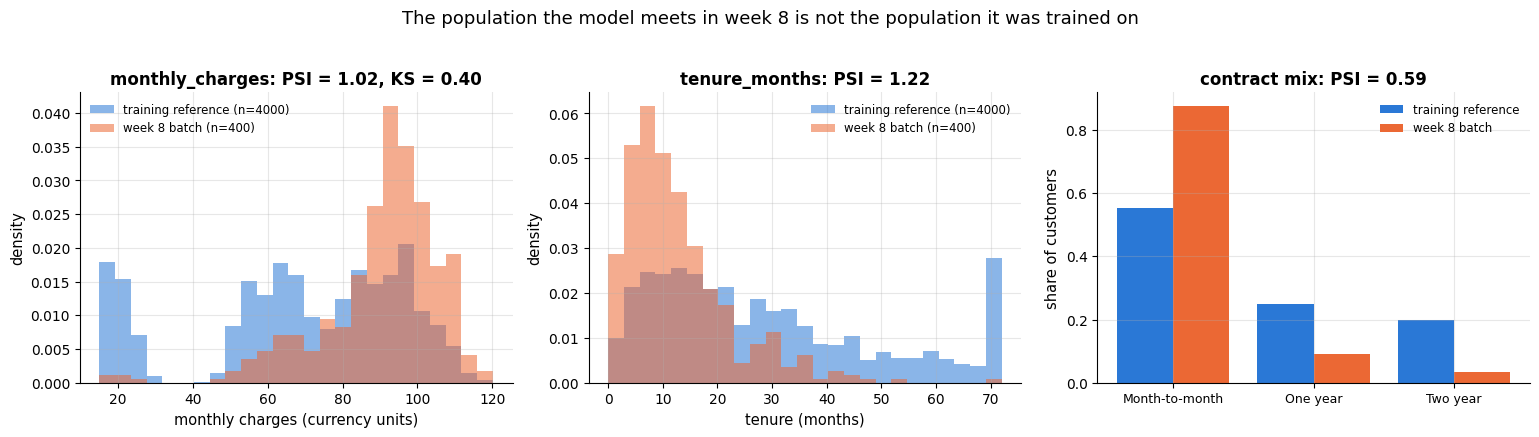

In [30]:
week8, labels8, scores8 = weekly_batches[8]       # the last simulated week
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2))
for ax, column, label in [(axes[0], "monthly_charges", "monthly charges (currency units)"),
                          (axes[1], "tenure_months", "tenure (months)")]:
    edges = np.histogram_bin_edges(X_train[column].dropna(), bins=25)    # 25 bins, shared by both histograms
    # density=True scales each histogram to area 1, so samples of different sizes can be compared
    ax.hist(X_train[column].dropna(), bins=edges, density=True, alpha=0.55, color=PALETTE[0],
            label=f"training reference (n={len(X_train)})")
    ax.hist(week8[column].dropna(), bins=edges, density=True, alpha=0.55, color=PALETTE[1],
            label=f"week 8 batch (n={len(week8)})")
    ax.set_xlabel(label)
    ax.set_ylabel("density")
    # a conditional expression picks the title: the KS value is shown for monthly_charges only
    ax.set_title(f"{column}: PSI = {monitor.loc[8, 'psi_' + column]:.2f}, "
                 f"KS = {ks_statistic(X_train[column].dropna(), week8[column].dropna()):.2f}"
                 if column == "monthly_charges" else
                 f"{column}: PSI = {monitor.loc[8, 'psi_' + column]:.2f}")
    ax.legend(fontsize=8.5)
levels = ["Month-to-month", "One year", "Two year"]
# the share of each contract type, in a fixed order; fillna(0) covers a type that does not occur in week 8
ref_share = X_train["contract"].value_counts(normalize=True).reindex(levels)
cur_share = week8["contract"].value_counts(normalize=True).reindex(levels).fillna(0)
xpos = np.arange(len(levels))
axes[2].bar(xpos - 0.2, ref_share, width=0.4, color=PALETTE[0], label="training reference")   # two bars per level
axes[2].bar(xpos + 0.2, cur_share, width=0.4, color=PALETTE[1], label="week 8 batch")
axes[2].set_xticks(xpos, levels, fontsize=9)
axes[2].set_ylabel("share of customers")
axes[2].set_title(f"contract mix: PSI = {monitor.loc[8, 'psi_contract']:.2f}")
axes[2].legend(fontsize=8.5)
fig.suptitle("The population the model meets in week 8 is not the population it was trained on",
             y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

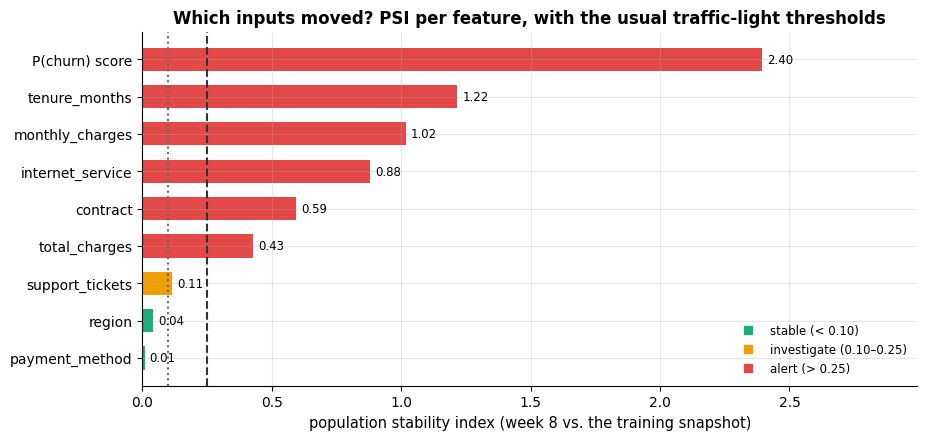

In [31]:
# which kind of PSI to compute for each column
drift_features = {"monthly_charges": "numeric", "tenure_months": "numeric", "total_charges": "numeric",
                  "support_tickets": "numeric", "contract": "categorical", "internet_service": "categorical",
                  "payment_method": "categorical", "region": "categorical"}
psi_now = {}
for column, kind in drift_features.items():
    psi_now[column] = (psi(X_train[column], week8[column]) if kind == "numeric"
                       else psi_categorical(X_train[column], week8[column]))
psi_now["P(churn) score"] = monitor.loc[8, "psi_score"]       # .loc[row, column]: week 8's PSI of the score
psi_series = pd.Series(psi_now).sort_values()                 # dict -> Series, smallest PSI first
severity = {"stable (< 0.10)": PALETTE[2], "investigate (0.10–0.25)": PALETTE[3], "alert (> 0.25)": PALETTE[7]}
# a chained conditional expression: the alert colour above 0.25, the investigate colour above 0.10, else stable
colours = [severity["alert (> 0.25)"] if v > 0.25 else
           severity["investigate (0.10–0.25)"] if v > 0.10 else severity["stable (< 0.10)"]
           for v in psi_series]
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.barh(psi_series.index, psi_series.to_numpy(), color=colours, height=0.62)
ax.axvline(0.10, color="0.4", ls=":", lw=1.5)      # the two thresholds are named in the legend
ax.axvline(0.25, color="0.2", ls="--", lw=1.5)
for i, v in enumerate(psi_series):
    ax.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=8.5)
ax.set_xlabel("population stability index (week 8 vs. the training snapshot)")
ax.set_xlim(0, max(psi_series) * 1.25)
ax.set_title("Which inputs moved? PSI per feature, with the usual traffic-light thresholds")
# empty lines that only carry a square marker and a label: custom legend entries, one per severity colour
handles = [plt.Line2D([], [], marker="s", ls="", color=c, label=n) for n, c in severity.items()]
ax.legend(handles=handles, loc="lower right", fontsize=8.5)
plt.show()

### 7.4 A monitoring dashboard

A monitoring system answers four questions, in this order of *availability*: is the service
running (immediately), are the inputs normal (immediately), are the predictions normal
(immediately), is the model still right (only when labels arrive). The dashboard below puts
them side by side, and panel 5 marks the part that is *not yet knowable*.

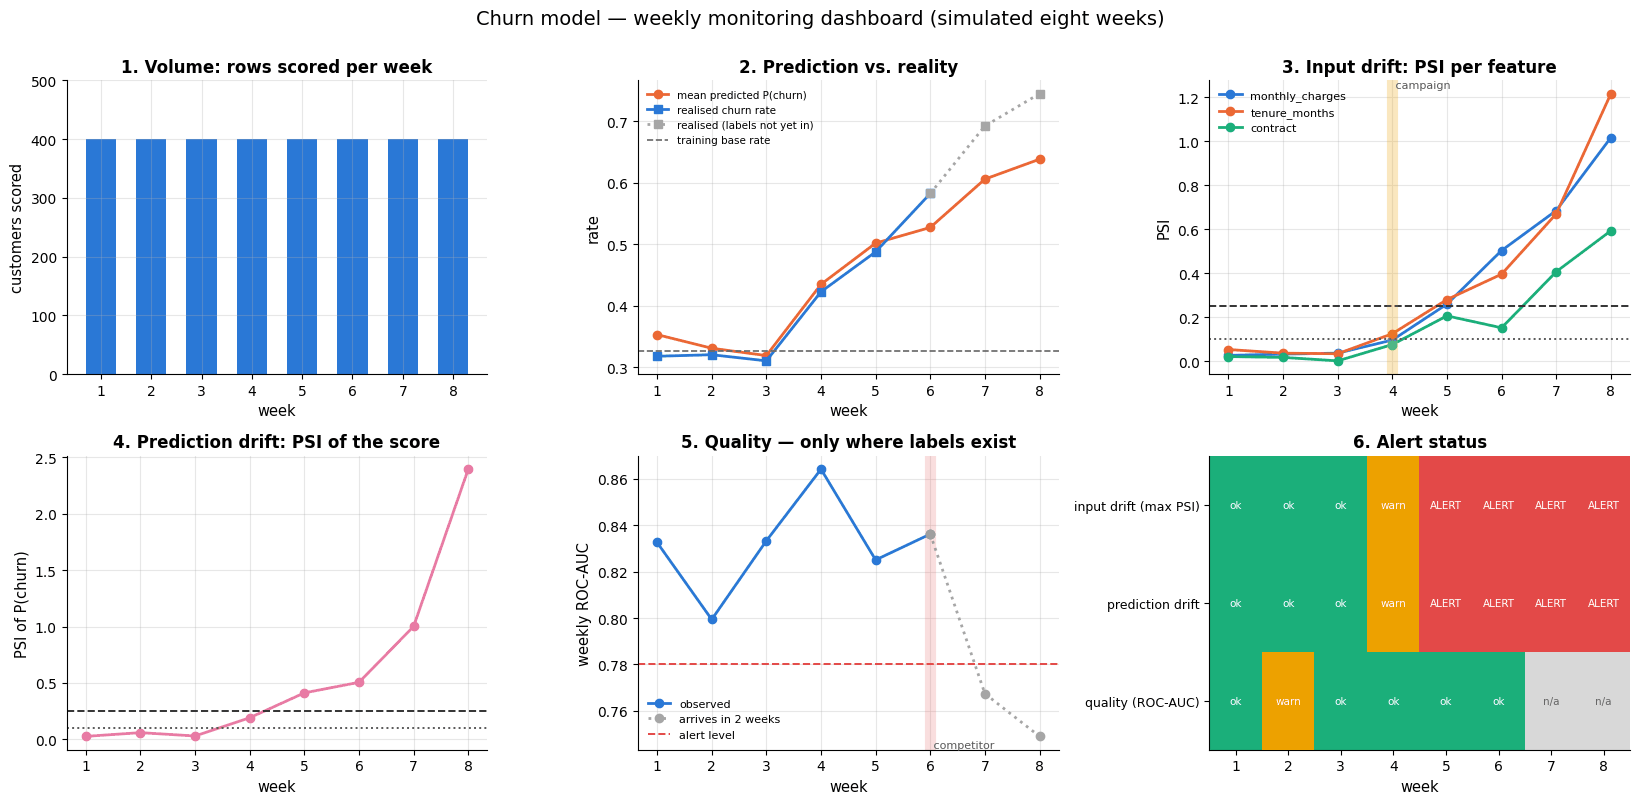

first input-drift alert: week 5 | first quality alert among weeks with labels: none


In [32]:
observed = monitor[monitor["labels_available"]]       # the weeks whose labels have arrived
pending = monitor[~monitor["labels_available"]]       # the weeks still waiting for labels
fig, axes = plt.subplots(2, 3, figsize=(16.5, 8))     # a 2 x 3 grid of panels, addressed as axes[row, col]
weeks = monitor.index.to_numpy()                      # the week numbers 1..8

# panel 1: volume
axes[0, 0].bar(weeks, monitor["n"], color=PALETTE[0], width=0.6)
axes[0, 0].set_ylim(0, monitor["n"].max() * 1.25)
axes[0, 0].set_title("1. Volume: rows scored per week")
axes[0, 0].set_xlabel("week")
axes[0, 0].set_ylabel("customers scored")

# panel 2: mean predicted probability against the realised churn rate
axes[0, 1].plot(weeks, monitor["mean_score"], marker="o", color=PALETTE[1], label="mean predicted P(churn)")
axes[0, 1].plot(observed.index, observed["realised_churn"], marker="s", color=PALETTE[0],
                label="realised churn rate")
# the last LABEL_DELAY + 1 weeks in dotted grey; starting at the last observed week makes the two lines connect
axes[0, 1].plot(monitor.index[-(LABEL_DELAY + 1):], monitor["realised_churn"].iloc[-(LABEL_DELAY + 1):],
                marker="s", ls=":", color="0.65", label="realised (labels not yet in)")
axes[0, 1].axhline(y_train.mean(), color="0.4", ls="--", lw=1.2, label="training base rate")
axes[0, 1].set_title("2. Prediction vs. reality")
axes[0, 1].set_xlabel("week")
axes[0, 1].set_ylabel("rate")
axes[0, 1].legend(fontsize=7.5, loc="upper left")

# panel 3: input drift, with the warn (0.10) and alert (0.25) levels as horizontal lines
for column, colour in [("psi_monthly_charges", PALETTE[0]), ("psi_tenure_months", PALETTE[1]),
                       ("psi_contract", PALETTE[2])]:
    axes[0, 2].plot(weeks, monitor[column], marker="o", color=colour,
                    label=column.replace("psi_", ""))
axes[0, 2].axhline(0.10, color="0.35", ls=":", lw=1.4)
axes[0, 2].axhline(0.25, color="0.2", ls="--", lw=1.4)
axes[0, 2].axvline(CAMPAIGN_WEEK, color=PALETTE[3], lw=8, alpha=0.25)    # a wide, faint line marks the campaign
# get_ylim()[1] is the top of the y-axis: the label sits at the top of that line
axes[0, 2].text(CAMPAIGN_WEEK, axes[0, 2].get_ylim()[1], " campaign", fontsize=8, va="top", color="0.35")
axes[0, 2].set_title("3. Input drift: PSI per feature")
axes[0, 2].set_xlabel("week")
axes[0, 2].set_ylabel("PSI")
axes[0, 2].legend(fontsize=8)

# panel 4: prediction drift
axes[1, 0].plot(weeks, monitor["psi_score"], marker="o", color=PALETTE[4])
axes[1, 0].axhline(0.10, color="0.35", ls=":", lw=1.4)
axes[1, 0].axhline(0.25, color="0.2", ls="--", lw=1.4)
axes[1, 0].set_title("4. Prediction drift: PSI of the score")
axes[1, 0].set_xlabel("week")
axes[1, 0].set_ylabel("PSI of P(churn)")

# panel 5: weekly ROC-AUC; the last 3 weeks dotted grey, because the last two have no labels yet
axes[1, 1].plot(observed.index, observed["roc_auc"], marker="o", color=PALETTE[0], label="observed")
axes[1, 1].plot(monitor.index[-3:], monitor["roc_auc"].iloc[-3:], marker="o", ls=":", color="0.65",
                label=f"arrives in {LABEL_DELAY} weeks")
axes[1, 1].axhline(config["monitoring"]["min_auc"], color=PALETTE[7], ls="--", lw=1.4, label="alert level")
axes[1, 1].axvline(COMPETITOR_WEEK, color=PALETTE[7], lw=8, alpha=0.18)
axes[1, 1].text(COMPETITOR_WEEK, axes[1, 1].get_ylim()[0], " competitor", fontsize=8, va="bottom",
                color="0.35")
axes[1, 1].set_title("5. Quality — only where labels exist")
axes[1, 1].set_xlabel("week")
axes[1, 1].set_ylabel("weekly ROC-AUC")
axes[1, 1].legend(fontsize=8, loc="lower left")

# panel 6: a traffic-light grid with one row per monitor and one column per week
monitors = ["input drift (max PSI)", "prediction drift", "quality (ROC-AUC)"]
status = np.zeros((3, WEEKS), dtype=int)              # status codes: 0 ok, 1 warn, 2 alert, 3 not available
max_psi = monitor[["psi_monthly_charges", "psi_tenure_months", "psi_contract"]].max(axis=1)   # largest per week
for j, week in enumerate(weeks):
    # chained conditional expressions: 2 above 0.25, otherwise 1 above 0.10, otherwise 0
    status[0, j] = 2 if max_psi[week] > 0.25 else 1 if max_psi[week] > 0.10 else 0
    status[1, j] = 2 if monitor.loc[week, "psi_score"] > 0.25 else 1 if monitor.loc[week, "psi_score"] > 0.10 else 0
    if not monitor.loc[week, "labels_available"]:
        status[2, j] = 3
    else:
        auc = monitor.loc[week, "roc_auc"]
        # alert below the configured min_auc, warn below 0.80, otherwise ok
        status[2, j] = 2 if auc < config["monitoring"]["min_auc"] else 1 if auc < 0.80 else 0
# one colour per status code: with vmin=0 and vmax=3 below, code k gets the k-th colour of the list
cmap = plt.matplotlib.colors.ListedColormap([PALETTE[2], PALETTE[3], PALETTE[7], "0.85"])
axes[1, 2].imshow(status, cmap=cmap, vmin=0, vmax=3, aspect="auto")
axes[1, 2].set_xticks(range(WEEKS), weeks)
axes[1, 2].set_yticks(range(3), monitors, fontsize=9)
for i in range(3):
    for j in range(WEEKS):
        # indexing the list of words with the status code picks the matching word
        axes[1, 2].text(j, i, ["ok", "warn", "ALERT", "n/a"][status[i, j]], ha="center", va="center",
                        fontsize=7.5, color="white" if status[i, j] < 3 else "0.4")
axes[1, 2].grid(False)
axes[1, 2].set_xlabel("week")
axes[1, 2].set_title("6. Alert status")
fig.suptitle("Churn model — weekly monitoring dashboard (simulated eight weeks)", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()
# max_psi[max_psi > 0.25].index[0] is the first week whose largest input PSI exceeds 0.25. The quality part is a
# conditional expression inside the f-string: "none" if every labelled week meets min_auc, else the first that does not
print(f"first input-drift alert: week {int(max_psi[max_psi > 0.25].index[0])} | "
      f"first quality alert among weeks with labels: "
      f"{'none' if (observed['roc_auc'] >= config['monitoring']['min_auc']).all() else int(observed[observed['roc_auc'] < config['monitoring']['min_auc']].index[0])}")

> **Key idea — the early warning is the input, the truth is the label.** In this simulation the
> PSI alarm fires in week 5. The competitor's effect on $P(y \mid \mathbf{x})$ starts in week 6
> and shows up in the weekly ROC-AUC of weeks 7–8, which we cannot see yet: those labels arrive
> two weeks later. A monitoring system that waits for accuracy to drop is always one label
> delay behind the world, so you monitor inputs and predictions *as well*, and you treat their
> alarms as the trigger for investigation, not proof of harm.

When labels are slow or absent, three partial substitutes help: **proxy labels** (a customer
who opens the retention e-mail), **a small labelled sample** bought quickly (call 100 flagged
customers next week), and **importance-weighted estimates** of the new error, which re-weight
the training distribution towards the current one (Quiñonero-Candela et al., 2009).

### 7.5 Deciding to retrain

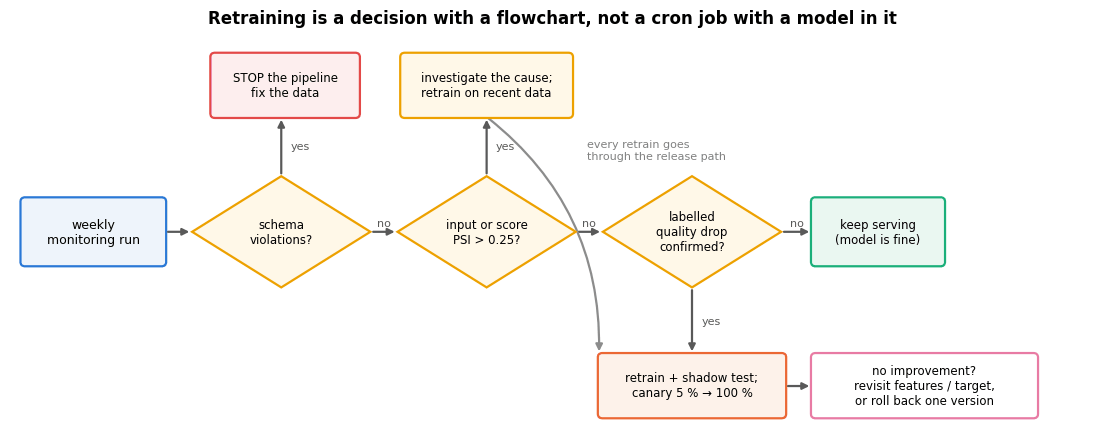

In [33]:
fig, ax = plt.subplots(figsize=(14, 5.2))
blank_axes(ax, (0, 14), (0, 5.4))


def diamond(x, y, w, h, text, fontsize=8.5):
    """Draw a labelled decision diamond (a flowchart question) filling the w x h area with lower-left corner (x, y).

    Unlike box() and arrow(), it takes no axes argument: it draws on the `ax` created at the top of this cell.
    """
    # plt.Polygon(points, closed=True) is the shape through the four corners: left, top, right, bottom
    ax.add_patch(plt.Polygon([(x, y + h / 2), (x + w / 2, y + h), (x + w, y + h / 2), (x + w / 2, y)],
                             closed=True, facecolor="#fff8e8", edgecolor=PALETTE[3], lw=1.6, zorder=2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize, zorder=3)


box(ax, 0.15, 2.25, 1.85, 0.9, "weekly\nmonitoring run", ec=PALETTE[0], fc="#eef4fb", fontsize=9)
# the three questions, asked from left to right
diamond(2.35, 1.95, 2.3, 1.5, "schema\nviolations?")
diamond(5.0, 1.95, 2.3, 1.5, "input or score\nPSI > 0.25?")
diamond(7.65, 1.95, 2.3, 1.5, "labelled\nquality drop\nconfirmed?")
# the outcomes: "no" to every question -> keep serving; each "yes" leads to the box above or below its diamond
box(ax, 10.35, 2.25, 1.7, 0.9, "keep serving\n(model is fine)", ec=PALETTE[2], fc="#eaf7f1", fontsize=8.5)
box(ax, 2.6, 4.25, 1.9, 0.85, "STOP the pipeline\nfix the data", ec=PALETTE[7], fc="#fdeeee", fontsize=8.5)
box(ax, 5.05, 4.25, 2.2, 0.85, "investigate the cause;\nretrain on recent data", ec=PALETTE[3],
    fc="#fff8e8", fontsize=8.5)
box(ax, 7.6, 0.2, 2.4, 0.85, "retrain + shadow test;\ncanary 5 % → 100 %", ec=PALETTE[1], fc="#fdf2ea",
    fontsize=8.5)
box(ax, 10.35, 0.2, 2.9, 0.85, "no improvement?\nrevisit features / target,\nor roll back one version",
    ec=PALETTE[4], fontsize=8.5)
arrow(ax, (2.0, 2.7), (2.35, 2.7))
arrow(ax, (3.5, 3.45), (3.5, 4.25))
arrow(ax, (4.65, 2.7), (5.0, 2.7), label="no", dy=0.05, fontsize=8)
arrow(ax, (6.15, 3.45), (6.15, 4.25))
arrow(ax, (7.3, 2.7), (7.65, 2.7), label="no", dy=0.05, fontsize=8)
arrow(ax, (8.8, 1.95), (8.8, 1.05))
arrow(ax, (9.95, 2.7), (10.35, 2.7), label="no", dy=0.05, fontsize=8)
for x_, y_ in [(3.5, 3.85), (6.15, 3.85), (8.8, 1.5)]:      # a "yes" next to each vertical arrow
    ax.text(x_ + 0.12, y_, "yes", fontsize=8, color="0.35", va="center")
arrow(ax, (10.0, 0.62), (10.35, 0.62))
arrow(ax, (6.15, 4.25), (7.6, 1.05), rad=-0.25, color="0.55")    # curved: a retrain also goes through the release path
ax.text(7.45, 3.8, "every retrain goes\nthrough the release path", fontsize=8, color="0.5", va="center")
ax.set_title("Retraining is a decision with a flowchart, not a cron job with a model in it", fontsize=12)
plt.show()

Three retraining policies, and when each is right:

| Policy | Mechanics | Use when |
|---|---|---|
| **Scheduled** | retrain every night/week on a rolling window | data arrive steadily, labels are fast, cost is low (notebook 16 retrains the demand forecaster this way) |
| **Triggered** | retrain when drift or quality crosses a threshold | retraining is expensive or risky, or drift is rare and bursty |
| **Continual / online** | update with every batch of labels | high-volume, fast-label problems (ads, recommendations) |

Whatever the trigger, the *release* is a separate decision, and it is made with the same tools
as the first release: run the test suite, compare against the incumbent on a common test set,
then deploy carefully.

- **Shadow deployment.** The new model scores live traffic in parallel; its predictions are
  logged, never used. It measures skew and latency under real load without risking anything.
- **Canary release.** Route 1 %, then 5 %, then 50 % of traffic to the new model, watching
  business and technical metrics; roll back automatically on a regression.
- **A/B test.** Randomise *users* (not requests) between models and measure the *business*
  outcome — retained revenue, not ROC-AUC. Fix the sample size and the horizon in advance;
  this is an experiment, with all the statistical care that implies.
- **Rollback.** Keeping `churn_v1` loadable is not sentimentality: the ability to return to the
  previous version in one command is what makes the other three safe.

> **Warning — feedback loops.** Our churn model triggers retention calls. Called customers
> churn less, so next quarter's training labels are *caused in part by the model's own
> predictions*. Naive retraining then learns "customers like these do not churn", exactly
> reversing the truth. The cures are the standard causal ones: hold out a small untreated
> control group, log the treatment as a feature, or model the uplift rather than the risk.

## 8. Governance: model cards, datasheets and lineage

Documentation is the part of MLOps that survives reorganisations. Mitchell et al. (2019)
proposed the **model card**: a short, structured document stating what the model is, what it
should and should not be used for, how it was evaluated, and on which groups its performance
was measured separately. Gebru et al. (2021) proposed the analogous **datasheet for datasets**
(motivation, composition, collection process, preprocessing, uses, distribution, maintenance).
Notebook 19 (*ethics, fairness, privacy and responsible ML*) treats both as instruments of
accountability; here we simply generate one from the metadata we already have, so that it
cannot drift away from the model it describes.

In [34]:
# disaggregated evaluation: v2's metrics on each slice of the test set (each contract type, each region)
slices = []
scored_test = X_test.assign(y=y_test.to_numpy(), p=p_test_v2)     # the test rows plus their label y and score p
for column in ["contract", "region"]:
    # groupby yields (value, rows with that value) pairs; observed=True only matters for categorical columns
    for level, group in scored_test.groupby(column, observed=True):
        if group["y"].nunique() == 2 and len(group) >= 50:     # ROC-AUC needs both classes; skip tiny slices
            slices.append({"slice": f"{column} = {level}", "n": len(group),
                           "churn rate": group["y"].mean(),
                           "ROC-AUC": roc_auc_score(group["y"], group["p"]),
                           "Brier": brier_score_loss(group["y"], group["p"])})
slice_table = pd.DataFrame(slices).sort_values("ROC-AUC").round(3)      # worst slice first
try:
    slice_markdown = slice_table.to_markdown(index=False)       # the table as Markdown text
except ImportError:                       # DataFrame.to_markdown needs the optional `tabulate`
    slice_markdown = slice_table.to_string(index=False)

# the card is one long f-string used as a template: every {...} is filled in from meta_v2, cp, config, y_train and
# the slice table, so the document always describes the model it was generated from
card = f"""# Model card — churn retention scorer ({meta_v2['name']}_{meta_v2['version']})

*Generated automatically from the model metadata on {meta_v2['created_at']}. Template after
Mitchell et al. (2019).*

## Model details
- **Owner / contact:** retention analytics team (add a real name and address here).
- **Version:** {meta_v2['version']} · run id `{meta_v2['run_id']}` · code revision `{meta_v2['code_revision']}`.
- **Type:** {meta_v2['estimator']} on {len(cp.NUMERIC) - 1} numeric, {len(cp.BINARY)} binary and
  {len(cp.CATEGORICAL)} one-hot encoded categorical features, inside a scikit-learn `Pipeline`.
- **Environment:** {meta_v2['environment']['python']} / scikit-learn {meta_v2['environment']['scikit-learn']}.
- **Training data:** `customer_churn.csv`, content hash `{meta_v2['data_hash'][:16]}`,
  {meta_v2['metrics']['n_train']:.0f} customers. *Simulated data shipped with this course.*

## Intended use
- **Primary use:** rank current subscribers by churn risk so that a retention team can call the
  top of the list within its weekly budget.
- **Primary users:** the retention team; the campaign scheduling job.
- **Out of scope:** pricing decisions, credit or eligibility decisions, any individual-level
  claim about *why* a customer will leave (use the explanations of notebook 17 for that, with
  their caveats), and any use on customers from a market the model was not trained on.

## Factors and evaluation
- Evaluated on a stratified 20 % hold-out ({meta_v2['metrics']['n_test']:.0f} customers) never used for
  fitting or selection.
- **Headline metrics:** ROC-AUC {meta_v2['metrics']['roc_auc']:.3f} ·
  average precision {meta_v2['metrics']['average_precision']:.3f} ·
  Brier score {meta_v2['metrics']['brier']:.3f} · decision threshold {meta_v2['decision_threshold']}.
- **Disaggregated performance** (slices with at least 50 customers):

{slice_markdown}

## Quantitative caveats
- The model is calibrated on a {y_train.mean():.1%} churn base rate; it will be miscalibrated if the
  population changes (see the monitoring plan).
- Behavioural tests enforce: risk never falls when support tickets rise, never rises when tenure
  rises, invariance to row order and to rounding of charges. Version v1 failed the first of these.

## Ethical considerations and risks
- Retention offers are a benefit; systematically under-scoring a group means withholding it.
  Compare slice metrics at every retraining (notebook 19).
- `senior_citizen` is used as a feature. Confirm with a lawyer and an ethicist whether that is
  appropriate in your jurisdiction, and check the fairness metrics of notebook 19 if it stays.
- Feedback loop: the campaign changes who churns. Keep an untreated control group.

## Maintenance
- **Monitoring:** PSI per input feature and for the score, weekly; alert at PSI > 0.25.
  ROC-AUC on the labelled cohort once labels arrive ({LABEL_DELAY}-week delay); alert below
  {config['monitoring']['min_auc']}.
- **Retraining:** on alert, or quarterly, whichever comes first; release via the test suite,
  a shadow week and a canary.
- **Rollback:** `load_model("churn", "v1")` restores the previous version.
"""
card_path = ARTIFACTS / "churn_model_card.md"
card_path.write_text(card)
print(f"wrote {card_path} ({len(card.split())} words)\n")      # .split() with no argument splits on any whitespace
print("\n".join(card.splitlines()[:26]))                         # the first 26 lines of the card

wrote artifacts/churn_model_card.md (511 words)

# Model card — churn retention scorer (churn_v2)

*Generated automatically from the model metadata on 2026-09-19T07:18:40+00:00. Template after
Mitchell et al. (2019).*

## Model details
- **Owner / contact:** retention analytics team (add a real name and address here).
- **Version:** v2 · run id `20260919T071840-b286b6` · code revision `no-git-repo`.
- **Type:** LogisticRegression on 4 numeric, 6 binary and
  4 one-hot encoded categorical features, inside a scikit-learn `Pipeline`.
- **Environment:** 3.11.15 / scikit-learn 1.8.0.
- **Training data:** `customer_churn.csv`, content hash `3ef3c77f3de62b5f`,
  4000 customers. *Simulated data shipped with this course.*

## Intended use
- **Primary use:** rank current subscribers by churn risk so that a retention team can call the
  top of the list within its weekly budget.
- **Primary users:** the retention team; the campaign scheduling job.
- **Out of scope:** pricing decisions, credit or e

The rest of governance is unglamorous and cheap: **lineage** (which data version, which code
revision, which run produced this artefact — our metadata sidecar is a miniature lineage
record), **access control** (who may read the training data, who may deploy), and **team
practice**:

- code review for ML: review the *data* changes and the metric deltas, not only the diff;
- CI that runs the test suite on every merge and a nightly job that re-runs the quality gate on fresh data;
- `nbstripout` (or `jupytext`) so notebooks diff as text instead of as base64 images;
- `papermill` / `nbconvert` to execute parameterised notebooks as scheduled jobs — exactly what
  `tools/build.py` does for this course;
- `pre-commit` hooks for formatting and linting, so review time goes to substance.

## 9. Scaling notes

Everything so far fits in memory. Three cheap moves buy an order of magnitude before you need a
cluster.

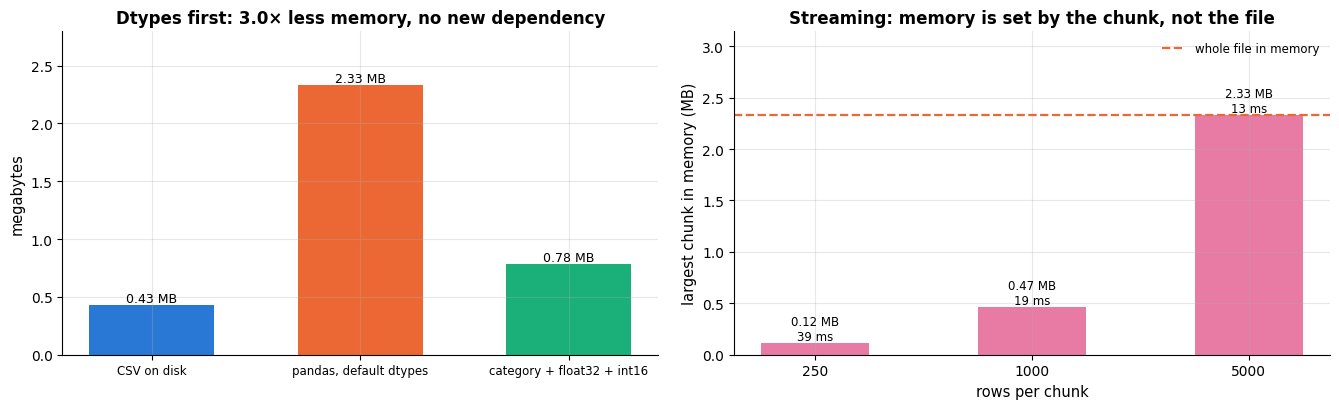

streamed churn rate 0.3265 == in-memory 0.3265


In [35]:
csv_bytes = cp.DATA_PATH.stat().st_size          # size of the CSV file on disk, in bytes
full = pd.read_csv(cp.DATA_PATH)                 # the whole file, with pandas' default dtypes
optimised = full.copy()
for column in ["region", "contract", "payment_method", "internet_service"]:
    optimised[column] = optimised[column].astype("category")     # each value -> a small integer code + one label list
for column in ["monthly_charges", "total_charges"]:
    optimised[column] = optimised[column].astype("float32")      # 4 bytes per value instead of 8
for column in ["senior_citizen", "has_partner", "tenure_months", "tech_support", "streaming",
               "support_tickets", "churned"]:
    optimised[column] = optimised[column].astype("int16")        # 2 bytes instead of 8; holds -32768..32767

# streaming: read the file in chunks of `size` rows, keep only running totals, and record the largest chunk in memory
chunk_sizes = [250, 1000, 5000]
chunk_stats = []
for size in chunk_sizes:
    t0 = time.perf_counter()
    total, n_rows, peak = 0.0, 0, 0
    for chunk in pd.read_csv(cp.DATA_PATH, chunksize=size):      # with chunksize, read_csv yields DataFrames
        total += float(chunk["churned"].sum())
        n_rows += len(chunk)
        peak = max(peak, chunk.memory_usage(deep=True).sum())    # bytes; deep=True includes the stored strings
    chunk_stats.append({"chunk": size, "peak_MB": peak / 1e6, "seconds": time.perf_counter() - t0,
                        "churn_rate": total / n_rows})
chunks = pd.DataFrame(chunk_stats)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
# file size, in-memory size with default dtypes, and with the optimised dtypes, all in MB
sizes_mb = [csv_bytes / 1e6, full.memory_usage(deep=True).sum() / 1e6,
            optimised.memory_usage(deep=True).sum() / 1e6]
bars = axes[0].bar(["CSV on disk", "pandas, default dtypes", "category + float32 + int16"], sizes_mb,
                   color=[PALETTE[0], PALETTE[1], PALETTE[2]], width=0.6)
axes[0].bar_label(bars, fmt="%.2f MB", fontsize=9)      # write each bar's value on top of it
axes[0].set_ylabel("megabytes")
axes[0].set_ylim(0, max(sizes_mb) * 1.2)
axes[0].set_title(f"Dtypes first: {sizes_mb[1] / sizes_mb[2]:.1f}× less memory, no new dependency")
axes[0].tick_params(axis="x", labelsize=8.5)
# str(c): the chunk sizes become category labels, evenly spaced, instead of numeric x positions
axes[1].bar([str(c) for c in chunks["chunk"]], chunks["peak_MB"], color=PALETTE[4], width=0.5)
axes[1].axhline(full.memory_usage(deep=True).sum() / 1e6, color=PALETTE[1], ls="--", lw=1.6,
                label="whole file in memory")
for i, (mb, s) in enumerate(zip(chunks["peak_MB"], chunks["seconds"])):
    axes[1].text(i, mb, f"{mb:.2f} MB\n{s * 1000:.0f} ms", ha="center", va="bottom", fontsize=8.5)
axes[1].set_xlabel("rows per chunk")
axes[1].set_ylabel("largest chunk in memory (MB)")
axes[1].set_ylim(0, full.memory_usage(deep=True).sum() / 1e6 * 1.35)
axes[1].set_title("Streaming: memory is set by the chunk, not the file")
axes[1].legend(fontsize=8.5)
plt.tight_layout()
plt.show()
print(f"streamed churn rate {chunks['churn_rate'].iloc[0]:.4f} == in-memory {full['churned'].mean():.4f}")

1. **Fix the dtypes.** Categories instead of strings, 32-bit floats, small integers. Free.
2. **Stop using CSV.** Parquet is columnar, compressed, typed and splittable: it reads the three
   columns you need without parsing the other twenty, and it keeps the dtypes you just fixed.
   `df.to_parquet(path)` / `pd.read_parquet(path, columns=[...])` needs `pyarrow`, an optional
   dependency absent from the environment that built this notebook, so the call is shown rather
   than run (`conda install -c conda-forge pyarrow`).
3. **Chunk or stream.** `pd.read_csv(..., chunksize=...)` (above) turns a file into an iterator
   of frames; aggregate incrementally and never hold more than one chunk. Training on chunks
   needs an estimator with `partial_fit` (`SGDClassifier`, `MiniBatchKMeans`) — the online
   learning route.

Beyond that: **Polars** (multi-threaded, lazy, larger-than-memory queries on one machine),
**Dask** (pandas/NumPy API across cores or machines), **Spark** (the JVM ecosystem's standard
for terabyte-scale ETL, with `pyspark.ml` for modelling). Move outward only when a machine is
genuinely too small — a cluster multiplies infrastructure debt, and Section 1.2 is about what
that costs. For model training specifically, remember that GPUs help dense linear algebra and
neural networks (a separate course), while the tree ensembles of notebook 10 are mostly
CPU-bound and scale by cores; measure cost per experiment, and cache expensive preprocessing
(`Pipeline(memory=...)`, notebook 12) before renting bigger hardware.

## Summary

- A model is 5 % of an ML system. The rest — configuration, data validation, feature code,
  serving, monitoring — is where the **technical debt** lives (Sculley et al., 2015), and the
  **ML test score** (Breck et al., 2017) is a cheap way to see which of the four areas is
  weakest.
- **Move prediction-time code out of the notebook into a module** and import it everywhere:
  training, batch scoring, the service and the tests then share one definition of a feature.
  This single move eliminates the most expensive class of production bug, training–serving skew.
- **Reproducibility = code hash + data hash + environment + seeds.** A fifteen-line JSON-Lines
  experiment log already buys you "which run produced this number?"; MLflow and W&B add a UI.
- **Persist bundles, not pickles:** the estimator plus metadata (versions, data hash, metrics,
  threshold, timestamp, run id). Verify the hash and the library version on load; remember that
  unpickling executes code and that the pickle references your module by name.
- **Test ML code in layers:** unit tests for feature functions, schema checks for data,
  behavioural tests (invariance, directional, minimum functionality) for the model, an
  integration test for the whole path and a quality gate for the release. A behavioural test
  found a real defect here that accuracy could not see.
- **Serve in batch unless you cannot.** Measure the tail of the latency distribution; batching
  amortises fixed cost by orders of magnitude.
- **Monitor inputs, predictions and quality**, in that order of availability. PSI and the KS
  statistic are ten lines each; labels arrive late, so input drift is your early warning.
  Retraining is a decision with a flowchart, and releases go through shadow, canary or A/B.
- **Write the model card with the model**, generated from its metadata, and keep the previous
  version loadable so that rollback is one command.

| Need | Reach for | Section |
|---|---|---|
| Share feature code between training and serving | an importable module | 2 |
| "Which run produced this?" | JSON-Lines run log, data hash, config file | 3 |
| Ship a model safely | `save_model`/`load_model` with metadata, hash and version check | 4 |
| Catch a bad batch | schema validation (`validate`, `pandera`) | 5.1 |
| Catch a bad model | behavioural tests + quality gate, run in CI | 5.2–5.3 |
| Score a file nightly | `score_batch.py` (argparse + bundle) | 6.2 |
| Answer in milliseconds | Flask/FastAPI + the *same* pipeline object | 6.3 |
| Detect a changing population | `psi`, `psi_categorical`, `ks_statistic` | 7.2 |
| Decide to retrain | drift + quality dashboard, retraining flowchart | 7.4–7.5 |
| Explain the model to a human | model card generated from metadata | 8 |
| Outgrow memory | dtypes → Parquet → chunks → Polars/Dask/Spark | 9 |

**Next steps:** notebook 19 (*ethics, fairness, privacy and responsible ML*) extends the model
card into fairness and privacy obligations; notebook 20 (*capstone project*) applies this whole
chapter to an end-to-end churn project with a business objective. Notebook 16 (*time series
forecasting*) is where the retraining cadence of a forecaster is set, and notebook 17 (*model
interpretability and explainability*) provides the debugging tools you will want the first time
a monitoring alert fires.

## Exercises

### Exercise 1 — Three unit tests for feature code (easy)
Add tests to `artifacts/test_churn_model.py` for `cp.add_features` covering: (a) a customer with
a missing `total_charges` gets `total_charges_missing == 1`; (b) `tickets_x_charges` is `NaN`
when `monthly_charges` is `NaN` (and decide whether that is what you want); (c) the function
never changes the dtype of `customer_id`. Re-run `run_tests()`.

<details><summary>Solution sketch</summary>

```py
def test_interaction_propagates_missing_charges():
    df = pd.DataFrame({"customer_id": ["a"], "signup_date": ["2024-01-01"], "tenure_months": [3],
                       "support_tickets": [2], "monthly_charges": [np.nan], "total_charges": [np.nan]})
    out = cp.add_features(df)
    assert out["total_charges_missing"].iloc[0] == 1
    assert np.isnan(out["tickets_x_charges"].iloc[0])
```
(b) is a design question: the median imputer downstream fills the `NaN` with the *training*
median of the interaction, which is not the product of the imputed parts. Documenting that is
worth more than changing it.
</details>

### Exercise 2 — A PSI alarm with a rolling reference (easy–medium)
Write `drift_alarm(reference, current, warn=0.1, alert=0.25)` returning `"ok" | "warn" |
"alert"` plus the PSI, and apply it to the eight weekly batches twice: once against the fixed
training snapshot, once against the *previous week*. Which reference detects the campaign
sooner, and which one would miss a slow drift entirely?

<details><summary>Solution sketch</summary>

A rolling one-week reference reacts to the *change* and is nearly blind to a slow, monotone
drift (each week looks like the last). The fixed training reference accumulates the whole
displacement and is the one that matters for the model, because the model was fitted on that
snapshot. Monitor both: the rolling one finds incidents, the fixed one finds staleness.
</details>

### Exercise 3 — A stricter `load_model` (medium)
Extend `load_model` so that it (a) refuses to load when the *major.minor* scikit-learn version
differs, (b) warns when the model is older than `max_age_days`, and (c) checks that the input
columns of an incoming frame match `meta["input_features"]` exactly, reporting missing and
unexpected columns. Add a test for each behaviour.

<details><summary>Solution sketch</summary>

```py
def _minor(v): return tuple(int(x) for x in v.split(".")[:2])
if _minor(trained_with) != _minor(sklearn.__version__):
    raise RuntimeError(...)
age = datetime.now(timezone.utc) - datetime.fromisoformat(meta["created_at"])
if age.days > max_age_days: print(f"[load_model] WARNING: model is {age.days} days old")
```
Model *staleness* is one of the model-development tests in the Breck rubric; this is the
cheapest way to implement it.
</details>

### Exercise 4 — Batch scoring with explanations (medium)
Extend `score_batch.py` with `--explain k`, which adds the `k` largest contributions
$w_j x_j$ (standardised units) per customer to the output CSV, using the coefficient vector of
the fitted logistic regression. Compare three customers' explanations with the local
explanations of notebook 17 and state one thing this cheap version cannot tell you.

<details><summary>Solution sketch</summary>

`design = model[:-1].transform(rows)`, then `contrib = design * model[-1].coef_[0]`; take
`np.argsort(-np.abs(contrib), axis=1)[:, :k]`. For a linear model these contributions *are* the
exact Shapley values up to the baseline (notebook 17), which is why the trick works — and why it
does not transfer to the boosted model, where you need TreeSHAP.
</details>

### Exercise 5 — A model card for another model (medium)
Write a model card for the energy-demand forecaster of notebook 16 or the loan model of
notebook 19. Include the forecast horizon or the fairness metrics as *headline* numbers, and
state the monitoring plan in terms the operator of that system would act on (what fires, how
often, what they do).

<details><summary>Solution sketch</summary>

For the forecaster, "intended use" must name the horizon (24 h ahead) and the retraining cadence,
"factors" should slice by hour of day and by season, and the monitoring plan is backtest MAE on
a rolling origin plus drift on temperature. For the loan model, disaggregate every metric by
group and add the selective-labels caveat: outcomes are observed only for approved applicants.
</details>

### Exercise 6 — Comparing retraining policies (hard)
Using the eight-week simulation, compare three policies: never retrain; retrain every week on
the last two weeks of *labelled* data (remember the two-week delay); retrain only when the PSI
alarm fires. Plot the weekly ROC-AUC of the three policies on one axis. Which wins, and what
does the label delay cost?

<details><summary>Solution sketch</summary>

Loop over weeks; for a retraining policy, fit `cp.train` on the concatenation of the batches
whose labels have arrived (`week - LABEL_DELAY`), then score the current week with that model.
Retraining helps once the concept drift is in the labelled window, i.e. two weeks after it
starts; before that, retraining on stale labels mostly re-learns the old concept and the gain
comes only from the changed covariate mix. The honest conclusion is that no policy can beat the
label delay — which is an argument for buying labels faster, not for a fancier model.
</details>

## References and further reading

### Textbooks

- Huyen, C. (2022). *Designing Machine Learning Systems*. O'Reilly. — The best single book on this notebook's subject; chapters 6–9 cover data distribution shifts, deployment and monitoring in depth.
- Burkov, A. (2020). *Machine Learning Engineering*. True Positive Inc. **(free to read online)** — http://www.mlebook.com — A practical checklist-style companion; strong on model serving and maintenance.
- Kleppmann, M. (2017). *Designing Data-Intensive Applications*. O'Reilly. — Not about ML, but the best explanation of the data systems every ML system is built on (batch vs. stream, schemas, evolution).

### Papers

- Sculley, D., et al. (2015). Hidden technical debt in machine learning systems. *Advances in Neural Information Processing Systems 28*. — The source of section 1.2; read it twice, a year apart.
- Breck, E., Cai, S., Nielsen, E., Salib, M., & Sculley, D. (2017). The ML test score: a rubric for ML production readiness and technical debt reduction. *Proceedings of IEEE Big Data 2017*. — The 28-test rubric used in section 1.3.
- Breck, E., Polyzotis, N., Roy, S., Whang, S. E., & Zinkevich, M. (2019). Data validation for machine learning. *Proceedings of MLSys 2019*. — How schema validation works at Google scale; the origin of the "data errors are the common errors" argument.
- Amershi, S., et al. (2019). Software engineering for machine learning: a case study. *Proceedings of ICSE-SEIP 2019*. — A nine-stage ML workflow observed in real software teams; the loop of section 1.1 is a compressed version of it.
- Paleyes, A., Urma, R.-G., & Lawrence, N. D. (2022). Challenges in deploying machine learning: a survey of case studies. *ACM Computing Surveys*, 55(6), 1–29. — A catalogue of what actually goes wrong, stage by stage.
- Polyzotis, N., Roy, S., Whang, S. E., & Zinkevich, M. (2018). Data lifecycle challenges in production machine learning: a survey. *SIGMOD Record*, 47(2), 17–28. — The data-management view of the same problems.
- Gama, J., Žliobaitė, I., Bifet, A., Pechenizkiy, M., & Bouchachia, A. (2014). A survey on concept drift adaptation. *ACM Computing Surveys*, 46(4), 1–37. — The reference taxonomy of drift and of adaptation strategies.
- Quiñonero-Candela, J., Sugiyama, M., Schwaighofer, A., & Lawrence, N. D. (Eds.) (2009). *Dataset Shift in Machine Learning*. MIT Press. — Covariate shift, prior shift and importance weighting, formally.
- Ribeiro, M. T., Wu, T., Guestrin, C., & Singh, S. (2020). Beyond accuracy: behavioral testing of NLP models with CheckList. *Proceedings of ACL 2020*, 4902–4912. — Introduced the invariance / directional / minimum-functionality vocabulary used in section 5.
- Pineau, J., et al. (2021). Improving reproducibility in machine learning research. *Journal of Machine Learning Research*, 22(164), 1–20. — The reproducibility checklist and what it is for.
- Sandve, G. K., Nekrutenko, A., Taylor, J., & Hovig, E. (2013). Ten simple rules for reproducible computational research. *PLoS Computational Biology*, 9(10), e1003285. **(free)**
- Wilson, G., et al. (2014). Best practices for scientific computing. *PLoS Biology*, 12(1), e1001745. **(free)** — Version control, testing and modularity for scientists; still the best short argument for leaving the notebook.
- Mitchell, M., et al. (2019). Model cards for model reporting. *Proceedings of FAT\* 2019*, 220–229. — The model-card template generated in section 8.
- Gebru, T., et al. (2021). Datasheets for datasets. *Communications of the ACM*, 64(12), 86–92. — The dataset counterpart.
- Siddiqi, N. (2006). *Credit Risk Scorecards: Developing and Implementing Intelligent Credit Scoring*. Wiley. — Where the PSI thresholds of section 7.2 come from; read them as conventions of that industry, not as universal constants.

### Documentation and online resources

- Google, *Rules of Machine Learning* (M. Zinkevich) — https://developers.google.com/machine-learning/guides/rules-of-ml — 43 rules of thumb from Google engineers; the first phase ("before machine learning" and "your first pipeline") is about exactly this notebook.
- scikit-learn, *Model persistence* (pickle, joblib, skops, ONNX and their security implications) — https://scikit-learn.org/stable/model_persistence.html
- MLflow — https://mlflow.org · Weights & Biases — https://docs.wandb.ai · DVC — https://dvc.org/doc — Tracking, artefacts and data versioning.
- pytest — https://docs.pytest.org · pandera — https://pandera.readthedocs.io · Great Expectations — https://docs.greatexpectations.io — Testing and data validation.
- Flask — https://flask.palletsprojects.com · FastAPI — https://fastapi.tiangolo.com — The two endpoints sketched in section 6.
- Feast (feature store) — https://docs.feast.dev · Apache Parquet — https://parquet.apache.org
- Polars — https://docs.pola.rs · Dask — https://docs.dask.org · Apache Spark (PySpark) — https://spark.apache.org/docs/latest/api/python/
- papermill — https://papermill.readthedocs.io · nbstripout — https://github.com/kynan/nbstripout · pre-commit — https://pre-commit.com — Notebooks in production and in version control.